In [2]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LightSource
import plotly.graph_objects as go

from plotly.subplots import make_subplots

import time
import matplotlib.patches as patches

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import gc

In [4]:
import plotly.io as pio

# Tell Plotly to render everything inside an isolated iframe
pio.renderers.default = "iframe"

## EIRP of Single antenna element

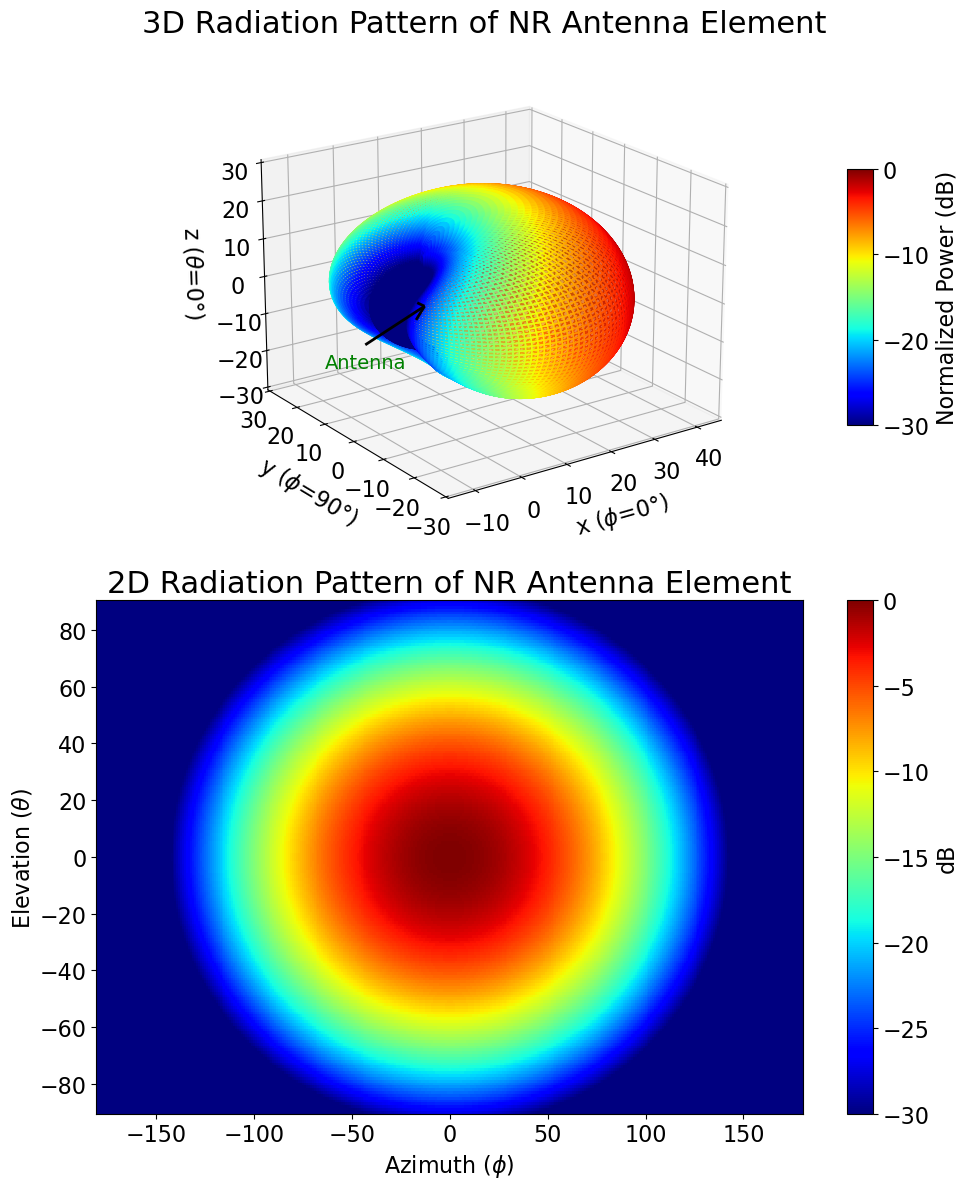

In [4]:
# Parameters 
theta_3db = 60.0
phi_3db = 90.0
A_max = 30.0
SLA_v = 30.0

# Grid Setup 
theta = np.linspace(0, 180, 181)
phi = np.linspace(-180, 180, 361)
Theta, Phi = np.meshgrid(theta, phi, indexing='ij') #Use 'ij' indexing so Theta and Phi map cleanly to matrix rows/columns

# 3GPP Attenuation Math 
A_v = 12 * ((Theta - 90) / theta_3db)**2
A_v = np.clip(A_v, a_min=None, a_max=SLA_v)

A_h = 12 * (Phi / phi_3db)**2
A_h = np.clip(A_h, a_min=None, a_max=A_max)

A_3D = A_v + A_h
A_3D = np.clip(A_3D, a_min=None, a_max=A_max)
power_dB = -A_3D

# 3D Coordinate Mapping
base_radius = 10
r = power_dB + A_max + base_radius

Theta_rad = np.radians(Theta)
Phi_rad = np.radians(Phi)

X = r * np.sin(Theta_rad) * np.cos(Phi_rad)
Y = r * np.sin(Theta_rad) * np.sin(Phi_rad)
Z = r * np.cos(Theta_rad)

# Plotting Setup
fig = plt.figure(figsize=(10, 12))

# 3D Radiation Pattern
ax1 = fig.add_subplot(211, projection='3d')

norm = plt.Normalize(vmin=-A_max, vmax=0)
colors = plt.cm.jet(norm(power_dB))

surf = ax1.plot_surface(X, Y, Z, facecolors=colors, rstride=2, cstride=2, 
                        antialiased=True, shade=False, alpha=0.5)
start_x, start_y, start_z = -35, -35, 15

# Draw a 3D arrow from the start coordinates pointing TO the origin (0,0,0)
# The vector (u, v, w) is simply the inverted start coordinates to reach zero
ax1.quiver(start_x, start_y, start_z, 
           -start_x, -start_y, -start_z, 
           color='black', linewidth=2, arrow_length_ratio=0.15, zorder=10)

# Place the red text just slightly below the arrow tail
ax1.text(start_x, start_y, start_z - 2, 'Antenna', color='green', 
         fontsize=14, ha='center', va='top', zorder=10)

mappable = plt.cm.ScalarMappable(cmap='jet', norm=norm)
mappable.set_array(power_dB)
cbar1 = fig.colorbar(mappable, ax=ax1, shrink=0.5, aspect=10, pad=0.12)
cbar1.set_label('Normalized Power (dB)', size=16)
cbar1.ax.tick_params(labelsize=16)

ax1.set_xlabel(r'x ($\phi$=0°)', labelpad=10,fontsize=16)
ax1.set_ylabel(r'y ($\phi$=90°)', labelpad=10,fontsize=16)
ax1.set_zlabel(r'z ($\theta$=0°)', labelpad=10,fontsize=16)
ax1.set_title('3D Radiation Pattern of NR Antenna Element',fontsize=22)
ax1.tick_params(axis='x', labelsize=16)
ax1.tick_params(axis='y', labelsize=16)
ax1.tick_params(axis='z', labelsize=16)

max_range = np.array([X.max()-X.min(), Y.max()-Y.min(), Z.max()-Z.min()]).max() / 2.0
mid_x = (X.max()+X.min()) * 0.5
mid_y = (Y.max()+Y.min()) * 0.5
mid_z = (Z.max()+Z.min()) * 0.5
ax1.set_xlim(mid_x - max_range, mid_x + max_range)
ax1.set_ylim(mid_y - max_range, mid_y + max_range)
ax1.set_zlim(mid_z - max_range, mid_z + max_range)

ax1.view_init(elev=20, azim=-125)

# 2D Heatmap
ax2 = fig.add_subplot(212)

# Convert standard spherical Theta (0 to 180) to the Armed paper's Elevation axis (-90 to 90)
# where 0 is dead center (broadside)
Elevation = 90 - Theta

heatmap = ax2.pcolormesh(Phi, Elevation, power_dB, cmap='jet', vmin=-A_max, vmax=0, shading='auto')

ax2.set_title('2D Radiation Pattern of NR Antenna Element',fontsize=22)
ax2.set_xlabel(r'Azimuth ($\phi$)',fontsize=16)
ax2.set_ylabel(r'Elevation ($\theta$)',fontsize=16)

# Set ticks 
ax2.set_xticks(np.arange(-150, 151, 50))
ax2.set_yticks(np.arange(-80, 81, 20))
ax2.tick_params(axis='x', labelsize=16)
ax2.tick_params(axis='y', labelsize=16)

# Add the colorbar
cbar2 = fig.colorbar(heatmap, ax=ax2)
cbar2.set_label('dB',size=16)
cbar2.ax.tick_params(labelsize=16)

plt.tight_layout()
#plt.savefig("Element_pattern.pdf", bbox_inches="tight",dpi=300)
plt.show()

## URA/UPA Antenna Panel

In [5]:
# PARAMETERS
f_c = 3.75e9  # 3.75 GHz
c = 3e8
lambda_c = c / f_c

# Single Element Pattern (3GPP TR 38.901 Defaults) 
theta_3db = 60.0  # Elevation HPBW
phi_3db = 90.0    # Azimuth HPBW
A_max = 30.0      # Front-to-back ratio limit
SLA_v = 30.0      # Sidelobe attenuation limit in elevation

# AAS Architecture -> Basically an UPA/URA 
# Assumption: We model a continuous Uniform Planar Array (UPA) per 
# the paper's text, deliberately ignoring the 0.174m subarray gap (Why is this done in the paper?)
# Subarray spacing is considered same as antenna element spacing
N1, N2 = 4, 4      # Panel dimensions: 4x4 Subarrays
M1, M2 = 2, 3      # Sub-array dimensions: 2 rows, 3 columns of elements
num_cols = N1 * M2 # 12 total columns
num_rows = N2 * M1 # 8 total rows
d_h = 0.044        # Horizontal element spacing (m)
d_v = 0.058        # Vertical element spacing (m)

# HIGH-RESOLUTION GRID SETUP
# 0.5 degree steps for an smooth 3D mesh
theta = np.linspace(0, 180, 361)  
phi = np.linspace(-180, 180, 721)
Theta, Phi = np.meshgrid(theta, phi, indexing='ij')

Theta_rad = np.radians(Theta)
Phi_rad = np.radians(Phi)

# SINGLE ELEMENT ATTENUATION (A_3D) , Element Pattern E(theta,phi)
A_v = 12 * ((Theta - 90) / theta_3db)**2
A_v = np.clip(A_v, a_min=None, a_max=SLA_v)

A_h = 12 * (Phi / phi_3db)**2
A_h = np.clip(A_h, a_min=None, a_max=A_max)

power_dB_element = -np.clip(A_v + A_h, a_min=None, a_max=A_max)

# OPTIMIZED ARRAY FACTOR (AF) CALCULATION (Vectorized) , AF(theta,phi)
Y_coords = []
Z_coords = []

# Generate contiguous grid coordinates
for c_idx in range(num_cols):
    for r_idx in range(num_rows):
        Y_coords.append(c_idx * d_h)
        Z_coords.append(r_idx * d_v)

Y_coords = np.array(Y_coords)
Z_coords = np.array(Z_coords)

# Center the array
Y_coords -= np.mean(Y_coords)
Z_coords -= np.mean(Z_coords)

# Vectorized Fast Math 
# Pre-compute trigonometric grids once
sin_Theta = np.sin(Theta_rad)
cos_Theta = np.cos(Theta_rad)
sin_Phi = np.sin(Phi_rad)

# Expand coordinates for 3D broadcasting: shape becomes (96, 1, 1)
Y_bc = Y_coords[:, np.newaxis, np.newaxis]
Z_bc = Z_coords[:, np.newaxis, np.newaxis]

# Calculate the phase tensor and sum across the array elements (axis 0)
phase_tensor = (2 * np.pi / lambda_c) * (Y_bc * (sin_Theta * sin_Phi) + Z_bc * cos_Theta)
AF = np.sum(np.exp(1j * phase_tensor), axis=0)

# Convert to dB
AF_dB = 20 * np.log10(np.abs(AF) / len(Y_coords) + 1e-12)

# PATTERN MULTIPLICATION (Total EIRP)
Total_dB = power_dB_element + AF_dB
#Total_dB = np.clip(Total_dB, -50, 0)  # CLIP to the minimum amount, here set to 50 dB

In [6]:
'''
# =====================================================================
# 6. PLOTTING SETUP & RENDERING (MATLAB Aesthetic)
# =====================================================================
fig = plt.figure(figsize=(14, 16))

# ---------------------------------------------------------
# Subplot 1: 3D Radiation Pattern (Final Paper Polish)
# ---------------------------------------------------------
ax1 = fig.add_subplot(211, projection='3d')

vmin_val = -50
Total_dB_clipped = np.clip(Total_dB, vmin_val, 0)
r = Total_dB_clipped - vmin_val

X = r * np.sin(Theta_rad) * np.cos(Phi_rad)
Y = r * np.sin(Theta_rad) * np.sin(Phi_rad)
Z = r * np.cos(Theta_rad)

norm = plt.Normalize(vmin=vmin_val, vmax=0)
colors = plt.cm.jet(norm(Total_dB_clipped))

# Soften the lighting: Lowered fraction and vert_exag for a less "plastic" look
ls = LightSource(azdeg=135, altdeg=45)
shaded_colors = ls.shade_rgb(colors, elevation=Z, fraction=0.7, vert_exag=0.2, blend_mode='soft')

surf = ax1.plot_surface(X, Y, Z, facecolors=shaded_colors, rstride=1, cstride=1, 
                        antialiased=True, shade=False)

# FIX: Completely hide the default Matplotlib 3D bounding box, background, and ticks
ax1.set_axis_off()

# Draw clean black axes lines originating from the center
axis_length = 45
ax1.plot([-10, axis_length], [0, 0], [0, 0], color='black', linewidth=1.5, zorder=1) # X
ax1.plot([0, 0], [-10, axis_length], [0, 0], color='black', linewidth=1.5, zorder=1) # Y
ax1.plot([0, 0], [0, 0], [-10, axis_length], color='black', linewidth=1.5, zorder=1) # Z

# Place the labels manually at the tips of the black lines
ax1.text(axis_length + 2, 0, 0, 'x - direction\n$(\\theta=90^\\circ, \\phi=0^\\circ)$', 
         ha='center', va='center', fontsize=11)
ax1.text(0, axis_length + 5, 0, 'y - direction\n$(\\theta=90^\\circ, \\phi=90^\\circ)$', 
         ha='center', va='center', fontsize=11)
ax1.text(0, 0, axis_length + 2, 'z - direction\n$(\\theta=0^\\circ, \\phi=0^\\circ)$', 
         ha='center', va='center', fontsize=11)

cbar1 = fig.colorbar(plt.cm.ScalarMappable(cmap='jet', norm=norm), ax=ax1, shrink=0.5, aspect=15, pad=0.05)
cbar1.set_label('Normalized Power (dB)')

# Lock the aspect ratio and viewing angle
max_range = np.array([X.max()-X.min(), Y.max()-Y.min(), Z.max()-Z.min()]).max() / 2.0
ax1.set_xlim(-max_range, max_range)
ax1.set_ylim(-max_range, max_range)
ax1.set_zlim(-max_range, max_range)
ax1.view_init(elev=20, azim=35)

# ---------------------------------------------------------
# Subplot 2: 2D Heatmap
# ---------------------------------------------------------
ax2 = fig.add_subplot(212)
Elevation = 90 - Theta
# Update vmin here as well to match the 3D plot
heatmap = ax2.pcolormesh(Phi, Elevation, Total_dB_clipped, cmap='jet', vmin=vmin_val, vmax=0, shading='auto')

ax2.set_title('2D Radiation Pattern of AAS (Broadside)')
ax2.set_xlabel(r'Azimuth ($\phi$)')
ax2.set_ylabel(r'Elevation ($\theta$)')
ax2.set_xticks(np.arange(-150, 151, 50))
ax2.set_yticks(np.arange(-80, 81, 20))

cbar2 = fig.colorbar(heatmap, ax=ax2)
cbar2.set_label('dB')

plt.tight_layout()
plt.show()
'''

'\n# =====================================================================\n# 6. PLOTTING SETUP & RENDERING (MATLAB Aesthetic)\n# =====================================================================\nfig = plt.figure(figsize=(14, 16))\n\n# ---------------------------------------------------------\n# Subplot 1: 3D Radiation Pattern (Final Paper Polish)\n# ---------------------------------------------------------\nax1 = fig.add_subplot(211, projection=\'3d\')\n\nvmin_val = -50\nTotal_dB_clipped = np.clip(Total_dB, vmin_val, 0)\nr = Total_dB_clipped - vmin_val\n\nX = r * np.sin(Theta_rad) * np.cos(Phi_rad)\nY = r * np.sin(Theta_rad) * np.sin(Phi_rad)\nZ = r * np.cos(Theta_rad)\n\nnorm = plt.Normalize(vmin=vmin_val, vmax=0)\ncolors = plt.cm.jet(norm(Total_dB_clipped))\n\n# Soften the lighting: Lowered fraction and vert_exag for a less "plastic" look\nls = LightSource(azdeg=135, altdeg=45)\nshaded_colors = ls.shade_rgb(colors, elevation=Z, fraction=0.7, vert_exag=0.2, blend_mode=\'soft\')\

In [7]:
# PLOTTING SETUP & RENDERING (Plotly Interactive Dashboard)

vmin_val = -50
Total_dB_clipped = np.clip(Total_dB, vmin_val, 0)

# Calculate radius (pinching to zero at the minimum dB value)
r = Total_dB_clipped - vmin_val

X = r * np.sin(Theta_rad) * np.cos(Phi_rad)
Y = r * np.sin(Theta_rad) * np.sin(Phi_rad)
Z = r * np.cos(Theta_rad)

# Set up a 2x1 subplot grid in Plotly. 
# explicitly tell Plotly the first row is a 3D scene.
fig = make_subplots(
    rows=2, cols=1,
    specs=[[{"type": "surface"}],
           [{"type": "heatmap"}]],
    vertical_spacing=0.1,
    subplot_titles=('3D Radiation Pattern of UPA', '2D Radiation Pattern of UPA (Broadside)')
)

# Interactive 3D Surface
stride = 1

fig.add_trace(go.Surface(
    x=X[::stride, ::stride], 
    y=Y[::stride, ::stride], 
    z=Z[::stride, ::stride],
    surfacecolor=Total_dB_clipped[::stride, ::stride],
    colorscale='Jet',
    cmin=vmin_val, 
    cmax=0,
    showscale=False #hide the 3D colorbar
), row=1, col=1)

fig.update_xaxes(title_font=dict(size=22, family='Arial', color='black'), row=1, col=1)
fig.update_yaxes(title_font=dict(size=22, family='Arial', color='black'), row=1, col=1)

# 2D Heatmap
# Plotly's Heatmap natively takes 1D arrays for x and y, and a 2D matrix for z
fig.add_trace(go.Heatmap(
    x=phi, 
    y=90-theta, 
    z=Total_dB_clipped,
    colorscale='Jet',
    zmin=vmin_val, 
    zmax=0,
    colorbar=dict(title='Power (dB)', len=0.45, y=0.25) # Position colorbar next to the 2D plot
), row=2, col=1)


# Formatting and Layout 

fig.update_layout(
    height=1000, 
    width=800,
    scene=dict(
        xaxis=dict(title='x-dir (Az=0°)', showbackground=False, showgrid=False, zerolinecolor='black'),
        yaxis=dict(title='y-dir (Az=90°)', showbackground=False, showgrid=False, zerolinecolor='black'),
        zaxis=dict(title='z-dir (El=0°)', showbackground=False, showgrid=False, zerolinecolor='black'),
        aspectmode='data', # This ensures the 3D beam isn't artificially stretched
        camera=dict(eye=dict(x=1.5, y=-1.5, z=0.5)) # Set default viewing angle
    )
)

# Update the 2D axis titles
fig.update_xaxes(title_text="Azimuth (φ)", tickvals=[-150, -100, -50, 0, 50, 100, 150], title_font=dict(size=22, family='Arial', color='black'), tickfont_size=18, row=2, col=1)
fig.update_yaxes(title_text="Elevation (θ)", tickvals=[-80, -60, -40, -20, 0, 20, 40, 60, 80], title_font=dict(size=22, family='Arial', color='black'),row=2,tickfont_size=18, col=1)
fig.update_annotations(font_size=30)
fig.show()

## Generate codebook and average heatmap , 4x4(X2) port , 2 Layer 

In [8]:
def compute_dft_vector(m, l, N1, N2, O1, O2):
    v = np.zeros(N1 * N2, dtype=complex)
    for c_port in range(N1):     # Horizontal (0 to 3)
        for r_port in range(N2): # Vertical (0 to 3)
            # 3GPP Column-Major Indexing:
            idx = (c_port * N2) + r_port
            phase = 2 * np.pi * ((c_port * m) / (O1 * N1) + (r_port * l) / (O2 * N2))
            v[idx] = np.exp(1j * phase)
    return v / np.sqrt(N1 * N2)

def generate_3gpp_codebook_32port_rank2():
    """
    Strict 3GPP TS 38.214 (Table 5.2.2.2.1-6) Type I Codebook
    Generates exactly 2048 matrices.
    """
    N1, N2 = 4, 4
    O1, O2 = 4, 4
    total_ports = N1 * N2 * 2 # 32
    
    codebook = []
    
    # 3GPP Rank 2 Co-phasing (i2 = 0, 1) -> Only 2 options!
    co_phasing = [1, 1j] 
    
    # 3GPP Rank 2 Spatial Offsets (i1,3 = 0, 1, 2, 3) mapping to (k1, k2)
    spatial_offsets = [
        (0, 0),         # Same beam
        (O1, 0),        # Azimuth offset
        (0, O2),        # Elevation offset
        (O1, O2)        # Diagonal offset
    ]
    
    # Loop over all base beams (i1,1 and i1,2)
    for m in range(N1 * O1):      
        for l in range(N2 * O2):  
            
            # Base beam for Layer 1
            v1 = compute_dft_vector(m, l, N1, N2, O1, O2)
            
            # Loop over the 4 spatial offsets for Layer 2
            for k1, k2 in spatial_offsets:
                
                # Calculate cyclic offset for the second beam
                m_prime = (m + k1) % (N1 * O1)
                l_prime = (l + k2) % (N2 * O2)
                
                # Offset beam for Layer 2
                v2 = compute_dft_vector(m_prime, l_prime, N1, N2, O1, O2)
                
                # 3. Loop over the 2 co-phasing factors
                for phi in co_phasing:
                    W = np.zeros((total_ports, 2), dtype=complex)
                    
                    # Layer 1 uses v1
                    W[0:16, 0] = v1
                    W[16:32, 0] = phi * v1
                    
                    # Layer 2 uses v2
                    W[0:16, 1] = v2
                    W[16:32, 1] = -phi * v2
                    
                    # Normalize for Rank 2
                    W = W / np.sqrt(2)
                    
                    codebook.append(W)
                    
    return codebook

W_codebook = generate_3gpp_codebook_32port_rank2()
print(f"Generated {len(W_codebook)} Precoding Matrices for (4,4) Rank 2.")

Generated 2048 Precoding Matrices for (4,4) Rank 2.


In [9]:
# --- Define the Physical Geometry and Analog M Matrix ---
num_elements = 192
num_ports = 32

y_coords = np.zeros(num_elements)
z_coords = np.zeros(num_elements)
M_analog = np.zeros((num_elements, num_ports), dtype=complex)

element_idx = 0
# THE TRUE GRID: 8 Rows (z-axis), 12 Columns (y-axis)
for r in range(8):
    for c in range(12):
        for pol in [0, 1]:
            # True physical dimensions in meters
            z_coords[element_idx] = (7 - r) * 0.058 # UPA
            '''
            ## ITU AAS 
            sub_r       = r // 2
            elem_in_sub = r % 2
            z_coords[element_idx] = sub_r * 0.174 + elem_in_sub * 0.058
            '''
            
            y_coords[element_idx] = c * 0.044
            
            
            # Subarrays: 2 rows tall, 3 columns wide
            sub_r = r // 2  
            sub_c = c // 3  
            
            # Match the 3GPP Column-Major Indexing
            port_id = (sub_c * 4) + sub_r
            
            if pol == 1:
                port_id += 16 # Pol0 -> Id 0-15 , Pol 1-> ID 16-31
                
            M_analog[element_idx, port_id] = 1.0 / np.sqrt(6)
            element_idx += 1

In [10]:
# --- Setup the Spatial Grid & Table I Element Pattern ---
azimuths = np.linspace(-180, 180, round(361*1.2))
elevations = np.linspace(-90, 90, round(181*1.2))
Az, El = np.meshgrid(azimuths, elevations)

# Flatten the grids for matrix multiplication
phi_flat = np.radians(Az.flatten())
theta_flat = np.radians(90 - El.flatten())

# TABLE I: Exact 3GPP Element Pattern (Az=90, El=60, Gain=5.3)
A_max = 30 # Standard 3GPP front-to-back ratio isolation
A_h = -np.clip(12 * (Az.flatten() / 90)**2, a_min=None, a_max=A_max) # Azimuth HPBW 90
A_v = -np.clip(12 * (El.flatten() / 60)**2, a_min=None, a_max=A_max) # Elevation HPBW 60
G_element_dB = 5.3 - np.clip(-(A_h + A_v), a_min=None, a_max=A_max) # Directional gain 5.3 dBi
G_element_linear = 10**(G_element_dB / 10) # Keep in linear for computation of average 

In [11]:
# --- The ULTRA-FAST Vectorized Evaluation ---
print("Evaluating Codebook (Vectorized)...")
start_time = time.time()

# A. Stack the entire codebook into one giant matrix
# W_codebook is a list of 2048 matrices of shape (32, 2)
# W_all will have shape (32, 4096)
W_all = np.hstack(W_codebook) 

# B. Project the entire codebook through the analog hardware
# Shape: (192, 32) @ (32, 4096) = (192, 4096)
W_eff_all = M_analog @ W_all

# C. Build the Steering Matrix for all flattened angles
# Shape: (192 elements, 65341 angles)
# Wavelength for 3.75 GHz
# 3.75 GHz Wavelength and Wavenumber
lam = 3e8 / 3.75e9  # 0.08 meters
k = 2 * np.pi / lam

# Apply wavenumber to the spatial geometry
phase_matrix = k * (
    y_coords[:, None] * np.sin(theta_flat) * np.sin(phi_flat) +
    z_coords[:, None] * np.cos(theta_flat)
)
# a_H is the conjugate transpose of the steering vector. 
# Shape: (65341 angles, 192 elements)
a_H = np.exp(1j * phase_matrix).T 

# D. The Master Equation (Calculates everything in one shot!)
# Shape: (65341, 192) @ (192, 4096) = (65341 angles, 4096 layers)
E_field_all = a_H @ W_eff_all

# E. Calculate Norm Squared (Power)
Power_all = np.abs(E_field_all)**2

# F. Group layers and average
# Reshape from (65341, 4096) -> (65341, 2048 matrices, 2 layers)
Power_reshaped = Power_all.reshape(-1, len(W_codebook), 2)

# Sum across the 2 layers (Rank 2) -> Shape: (65341, 2048)
Power_PMs = np.sum(Power_reshaped, axis=2)

# Average across all 2048 Codebook Matrices -> Shape: (65341,)
EIRP_avg_flat = np.mean(Power_PMs, axis=1)

print(f"Finished in {time.time() - start_time:.2f} seconds!")

# Final Processing and Plotting
# Apply the Table I physical element pattern
Total_EIRP_linear_flat = EIRP_avg_flat * G_element_linear

# Reshape back to 2D for plotting (181, 361)
Total_EIRP_linear = Total_EIRP_linear_flat.reshape(El.shape)

# Convert to dB and normalize to 0 dB max
Total_EIRP_dB = 10 * np.log10(Total_EIRP_linear + 1e-12)
Total_EIRP_dB = Total_EIRP_dB - np.max(Total_EIRP_dB)

Evaluating Codebook (Vectorized)...
Finished in 6.08 seconds!


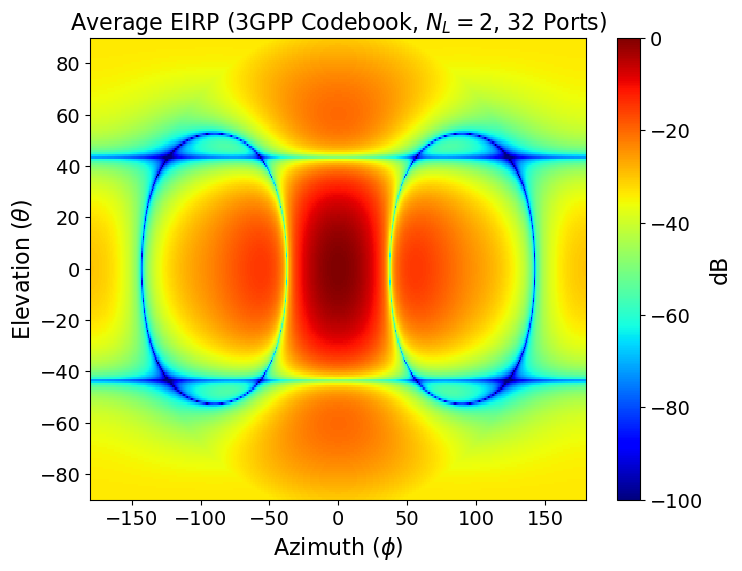

In [12]:
# Plotting using Object-Oriented Matplotlib
fig, ax = plt.subplots(figsize=(8, 6))
mesh = ax.pcolormesh(Az, El, Total_EIRP_dB, cmap='jet', vmin=-100, vmax=0, shading='auto')
cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label('dB',fontsize=16)
cbar.ax.tick_params(labelsize=14)

ax.set_title(r'Average EIRP (3GPP Codebook, $N_L=2$, $32$ Ports)',fontsize=16)
ax.set_xlabel(r'Azimuth ($\phi$)',fontsize=16)
ax.set_ylabel(r'Elevation ($\theta$)',fontsize=16)
ax.tick_params(axis='both', labelsize=14)
ax.set_xlim([-180, 180])
ax.set_ylim([-90, 90])
#plt.savefig("Average_EIRP.pdf", bbox_inches="tight",dpi=300)
plt.show()

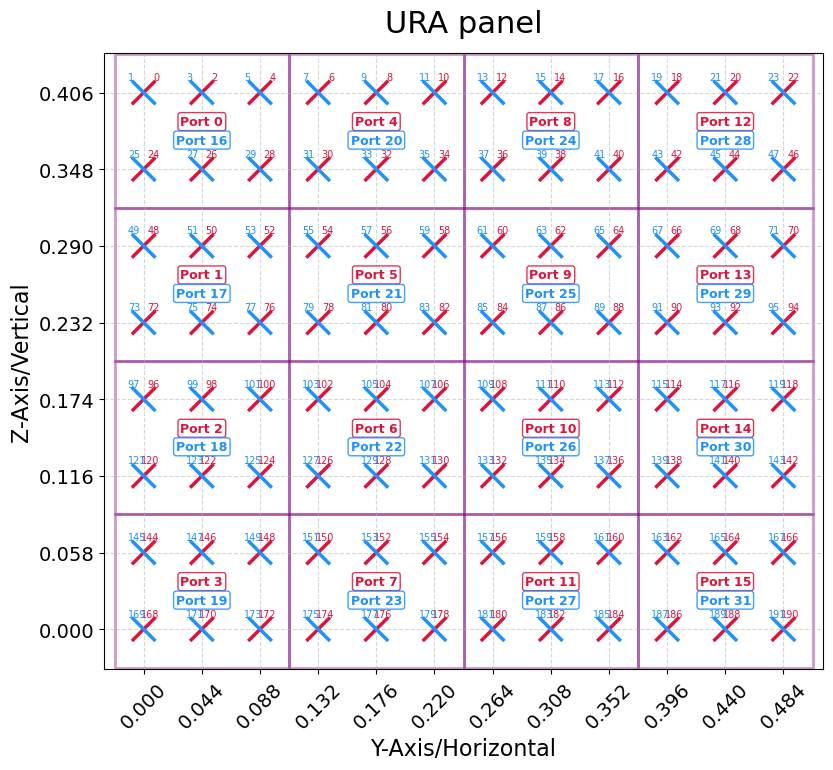

In [13]:
# Assume M_analog, y_coords, z_coords are already defined in memory 
# We extract the physical spacing dynamically from the coordinates
unique_y = np.unique(y_coords)
unique_z = np.unique(z_coords)
d_y = np.diff(unique_y)[0] if len(unique_y) > 1 else 0.044
d_z = np.diff(unique_z)[0] if len(unique_z) > 1 else 0.058

# Initialize Figure and Axes
fig, ax = plt.subplots(figsize=(12, 8))

# Define distinct colors for Polarizations
color_pol0 = 'crimson'     # Red for Pol 0 (+45 deg)
color_pol1 = 'dodgerblue'  # Blue for Pol 1 (-45 deg)

# Half-length of the slanted lines representing the antennas
l = 0.008 

# Plot Antenna Elements directly from the coordinate arrays
num_elements = len(y_coords)
for i in range(num_elements):
    y = y_coords[i]
    z = z_coords[i]
    
    # In our generation loop, even indices are Pol 0, odd indices are Pol 1
    is_pol0 = (i % 2 == 0)
    
    if is_pol0:
        # Draw +45 degree slant (/)
        ax.plot([y - l, y + l], [z - l, z + l], color=color_pol0, lw=2.5)
        # Annotate index slightly offset
        ax.text(y + l*1.5, z + l, f"{i}", fontsize=7, color=color_pol0, ha='right', va='bottom')
    else:
        # Draw -45 degree slant (\)
        ax.plot([y - l, y + l], [z + l, z - l], color=color_pol1, lw=2.5)
        # Annotate index slightly offset
        ax.text(y - l*1.5, z + l, f"{i}", fontsize=7, color=color_pol1, ha='left', va='bottom')

# Dynamically Draw Subarrays by analyzing M_analog
# We only need to loop through the first 16 ports (Pol 0) to find the bounding boxes,
# because the corresponding Pol 1 port (port + 16) shares the exact same spatial bounding box.
num_ports_per_pol = M_analog.shape[1] // 2

for port_0 in range(num_ports_per_pol):
    port_1 = port_0 + num_ports_per_pol
    
    # Find all element indices where M_analog has a non-zero weight for this port
    connected_elements = np.where(np.abs(M_analog[:, port_0]) > 0)[0]
    
    if len(connected_elements) == 0:
        continue
        
    # Get the spatial coordinates of these specific elements
    y_sub = y_coords[connected_elements]
    z_sub = z_coords[connected_elements]
    
    # Calculate bounding box with padding
    y_min, y_max = np.min(y_sub) - (d_y / 2), np.max(y_sub) + (d_y / 2)
    z_min, z_max = np.min(z_sub) - (d_z / 2), np.max(z_sub) + (d_z / 2)
    
    width = y_max - y_min
    height = z_max - z_min
    
    # Draw Subarray Boundary
    rect = patches.Rectangle((y_min, z_min), width, height, 
                             linewidth=2, edgecolor='purple', facecolor='none', alpha=0.4)
    ax.add_patch(rect)
    
    # Annotate the Ports with their respective polarization colors
    center_y = y_min + width / 2
    center_z = z_min + height / 2
    
    # Port 0 Label (Red)
    ax.text(center_y, center_z + 0.007, f"Port {port_0}", 
            ha='center', va='center', color=color_pol0, fontweight='bold', fontsize=9,
            bbox=dict(facecolor='white', alpha=0.85, edgecolor=color_pol0, boxstyle='round,pad=0.2'))
    
    # Port 1 Label (Blue)
    ax.text(center_y, center_z - 0.007, f"Port {port_1}", 
            ha='center', va='center', color=color_pol1, fontweight='bold', fontsize=9,
            bbox=dict(facecolor='white', alpha=0.85, edgecolor=color_pol1, boxstyle='round,pad=0.2'))

# Format Axes using the true array coordinates
ax.set_xticks(unique_y)
ax.set_yticks(unique_z)

# Format the tick labels to 3 decimal places so they are clean
ax.set_xticklabels([f"{val:.3f}" for val in unique_y], rotation=45)
ax.set_yticklabels([f"{val:.3f}" for val in unique_z])

ax.set_aspect('equal')
ax.set_title("URA panel", fontsize=22, pad=15)
ax.set_xlabel("Y-Axis/Horizontal", fontsize=16)
ax.set_ylabel("Z-Axis/Vertical", fontsize=16)

# Grid lines will now perfectly intersect the antenna elements
ax.grid(True, linestyle='--', alpha=0.5)

# Adjust plot limits for clean margins
padding = 0.03
ax.set_xlim(np.min(unique_y) - padding, np.max(unique_y) + padding)
ax.set_ylim(np.min(unique_z) - padding, np.max(unique_z) + padding)

# Change font size for BOTH axes
ax.tick_params(axis='both', labelsize=14)
#plt.savefig("TX Panel.pdf", bbox_inches="tight",dpi=300)
plt.show()

## Beamnulling 

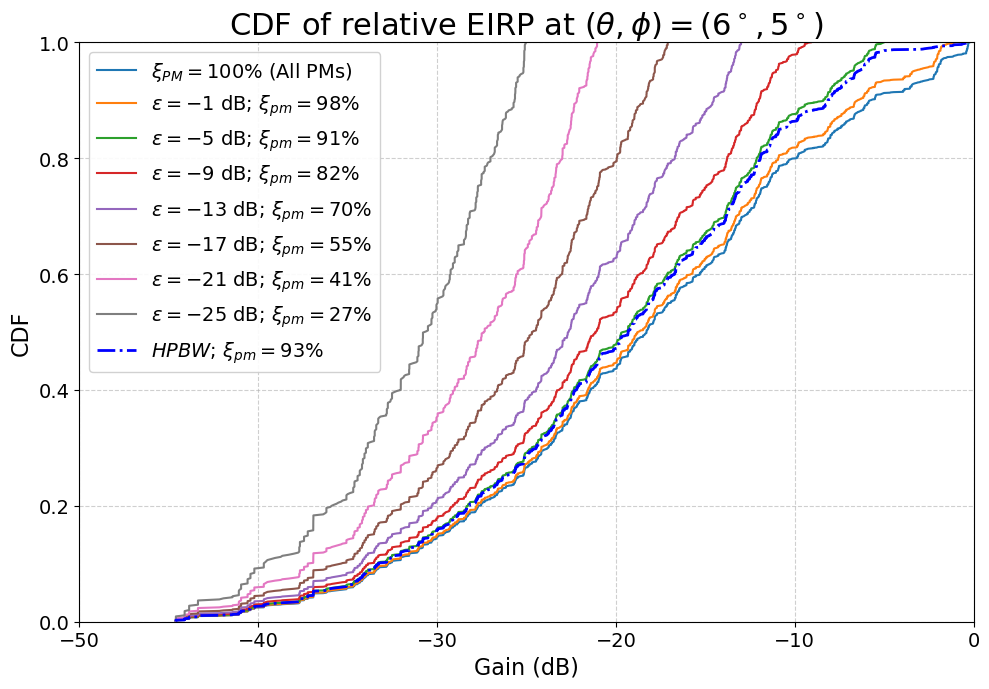

In [14]:
# PER-CODEBOOK NORMALIZATION (The Fix)
# Apply the element pattern to all matrices across all angles
# Power_PMs shape: (65341, 2048) | G_element_linear shape: (65341,)
All_EIRP_linear = Power_PMs * G_element_linear[:, np.newaxis]

# Convert the entire environment to dB
All_EIRP_dB = 10 * np.log10(All_EIRP_linear + 1e-12)

# FIND THE MAX FOR EACH INDIVIDUAL CODEBOOK
# axis=0 searches down the 65341 angles for each of the 2048 columns
# local_max_dB shape: (2048,)
local_max_dB = np.max(All_EIRP_dB, axis=0)

# Normalize each codebook by its own peak
# We use np.newaxis to broadcast the (2048,) array correctly across the columns
All_EIRP_Normalized = All_EIRP_dB - local_max_dB[np.newaxis, :]

# EXTRACT THE TARGET LOCATION
# ==========================================
# Radar location: Elevation = 6 deg, Azimuth = 5 deg
target_az = 5
target_el = 6 

# Find the corresponding 1D flattened index
az_idx = np.argmin(np.abs(azimuths - target_az))
el_idx = np.argmin(np.abs(elevations - target_el))
flat_idx = el_idx * len(azimuths) + az_idx

# Extract the 2048 normalized EIRP values hitting the victim
EIRP_target_dB = All_EIRP_Normalized[flat_idx, :]


# ==========================================
# HPBW-BASED PM SELECTION (Algorithm 2)
# ==========================================
# HPBW values from the paper (Section II-A)
theta_HPBW = 8.74 
phi_HPBW = 7.68   

# Find the index of the peak EIRP for each of the 2048 codebooks
# All_EIRP_dB is shape (65341, 2048). axis=0 finds the max down the angles.
peak_flat_indices = np.argmax(All_EIRP_dB, axis=0)

# Convert flat indices back to Azimuth and Elevation angles
peak_el_indices = peak_flat_indices // len(azimuths)
peak_az_indices = peak_flat_indices % len(azimuths)

peak_els = elevations[peak_el_indices]
peak_azs = azimuths[peak_az_indices]

# Check if the target is INSIDE the HPBW box for each PM
target_in_el_hpbw = np.abs(target_el - peak_els) <= (theta_HPBW / 2)
target_in_az_hpbw = np.abs(target_az - peak_azs) <= (phi_HPBW / 2)
target_in_box = target_in_el_hpbw & target_in_az_hpbw

# We KEEP the PMs where the target is OUTSIDE the box
hpbw_survivor_mask = ~target_in_box

# Extract the EIRP values for the surviving PMs
EIRP_target_HPBW = EIRP_target_dB[hpbw_survivor_mask]
xi_pm_hpbw = (len(EIRP_target_HPBW) / 2048) * 100


# COMPUTE AND PLOT CDFs
thresholds = [0, -1, -5, -9, -13, -17, -21, -25] 

fig, ax = plt.subplots(figsize=(10, 7))

# Plot Algorithm 1 (Thresholds)
for epsilon in thresholds:
    if epsilon == 0:
        subset = EIRP_target_dB
        label = r"$\xi_{PM} = 100\%$ (All PMs)"
    else:
        # Keep only the Precoding Matrices that produce EIRP <= epsilon
        subset = EIRP_target_dB[EIRP_target_dB <= epsilon]
        
        # Calculate the percentage of surviving matrices
        xi_pm = (len(subset) / 2048) * 100
        label = rf"$\epsilon = {epsilon}$ dB; "+ r"$\xi_{pm}$" + rf"$ = {xi_pm:.0f}\%$"
        
    if len(subset) > 0:
        sorted_subset = np.sort(subset)
        cdf = np.arange(1, len(sorted_subset) + 1) / len(sorted_subset)
        ax.plot(sorted_subset, cdf, lw=1.5, label=label)

# Plot Algorithm 2 (HPBW)
if len(EIRP_target_HPBW) > 0:
    sorted_hpbw = np.sort(EIRP_target_HPBW)
    cdf_hpbw = np.arange(1, len(sorted_hpbw) + 1) / len(sorted_hpbw)
    label_hpbw = r"$HPBW$; $\xi_{pm}$" + rf"$ = {xi_pm_hpbw:.0f}\%$"
    # Using a dash-dot line to distinguish it from the threshold curves
    ax.plot(sorted_hpbw, cdf_hpbw, linestyle='-.', color='blue', lw=2, label=label_hpbw)


# PLOT FORMATTING
ax.set_title(rf"CDF of relative EIRP at $(\theta, \phi) = ({target_el}^\circ, {target_az}^\circ)$", 
             fontsize=22)
ax.set_xlabel("Gain (dB)", fontsize=16)
ax.set_ylabel("CDF", fontsize=16)

ax.set_xlim([-50, 0])
ax.set_ylim([0, 1])

ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper left', fontsize=14, framealpha=0.9)
ax.tick_params(axis='both', labelsize=14)

plt.tight_layout()
#plt.savefig("BeamNulling.pdf", bbox_inches="tight",dpi=300)
plt.show()

In [15]:
eps_15_survivor_mask = EIRP_target_dB <= -15
eps_15_survivor_mask #for later use

array([False, False, False, ..., False,  True, False], shape=(2048,))

In [16]:
eps_15_survivor_mask.mean()

np.float64(0.61181640625)

## Link Level Simulation - Phase 1

In [104]:
#!pip install sionna

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

import os

# Point DrJit strictly to the Homebrew LLVM 16 installation
os.environ["DRJIT_LIBLLVM_PATH"] = "/opt/homebrew/opt/llvm@16/lib/libLLVM.dylib"

import sionna
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver

print("Sionna RT loaded successfully!")

# Sionna 2.x (PyTorch) Imports
import sionna.phy as sn_phy

import sionna_vispy

from sionna.rt import PathSolver

from sionna.rt import subcarrier_frequencies

Sionna RT loaded successfully!


In [13]:
## SISO in AWGN Channel 

class Phase1VanillaPipeline(nn.Module):
    def __init__(self):
        super().__init__()
        
        # 1. 3GPP Configuration from the paper
        self.k = 490  # Information bits
        self.n = 1024 # Codeword length (Rate = 490/1024)
        self.num_bits_per_symbol = 4 # 4 bits per symbol = 16-QAM
        self.coderate = self.k / self.n
        
        # 2. Initialize Sionna 2.0 (PyTorch) Components
        self.encoder = sn_phy.fec.ldpc.LDPC5GEncoder(self.k, self.n)
        self.decoder = sn_phy.fec.ldpc.LDPC5GDecoder(self.encoder, num_iter=8, return_infobits=True)
        self.mapper = sn_phy.mapping.Mapper("qam", self.num_bits_per_symbol)
        self.demapper = sn_phy.mapping.Demapper("app", "qam", self.num_bits_per_symbol)

    def forward(self, batch_size, ebno_db, device):
        # Step 1: Generate random information bits
        b = torch.randint(0, 2, (batch_size, self.k), dtype=torch.float32, device=device)
        
        # Step 2: 3GPP LDPC Encoding
        c = self.encoder(b)
        
        # Step 3: Map bits to 16-QAM complex symbols
        x = self.mapper(c)
        
        # Step 4: AWGN Channel Math
        # Convert Eb/N0 (SNR per bit) in dB to Noise Variance (N0)
        snr_linear = 10.0 ** (ebno_db / 10.0)
        no = 1.0 / (snr_linear * self.coderate * self.num_bits_per_symbol)
        
        # Add complex Gaussian noise directly via PyTorch
        noise = torch.randn_like(x, dtype=torch.cfloat) * np.sqrt(no / 2.0)
        y = x + noise
        
        # Step 5: Demap symbols back to soft-bit Log-Likelihood Ratios (LLRs)
        no_tensor = torch.tensor(no, dtype=torch.float32, device=device)
        llr = self.demapper(y, no_tensor)
        
        # Step 6: LDPC Decoding
        b_hat = self.decoder(llr)
        
        return b, b_hat

# ==========================================
print("Initializing Phase 1 PyTorch Simulator...")

# Detect Kaggle's GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing on: {device}")

# Load the model onto the GPU
model = Phase1VanillaPipeline().to(device)

# SNR points to sweep (Eb/N0 in dB)
ebno_dbs = np.arange(-2, 6, 1.0)
ber_results = []

# ==========================================
# KAGGLE NOTEBOOK EXECUTION BLOCK (UPDATED)
# ==========================================
print("Initializing Phase 1 PyTorch Simulator...")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing on: {device}")

model = Phase1VanillaPipeline().to(device)

# SNR points to sweep (Eb/N0 in dB)
ebno_dbs = np.arange(-10, 4, 1.0)
ber_results = []

# Memory-safe batch size for LDPC Belief Propagation
batch_size = 1000  

# Monte Carlo Stopping Conditions
target_errors = 100
max_batches = 100 # Safety limit (5000 batches * 1000 packets = 5 million packets max per SNR)

print("Running Monte Carlo batches...")

with torch.no_grad(): 
    for ebno_db in ebno_dbs:
        
        total_errors = 0
        total_bits = 0
        batches_run = 0
        
        # The exact loop you suggested!
        while total_errors < target_errors and batches_run < max_batches:
            
            b, b_hat = model(batch_size, ebno_db, device)
            
            errors = torch.sum(b != b_hat).item()
            total_errors += errors
            total_bits += b.numel()
            batches_run += 1
            
        ber = total_errors / total_bits
        ber_results.append(ber)
        
        print(f"Eb/N0: {ebno_db:5.1f} dB | Errors: {total_errors:5.0f} | Bits: {total_bits:10.0f} | BER: {ber:.6e}")

Initializing Phase 1 PyTorch Simulator...
Executing on: cuda
Initializing Phase 1 PyTorch Simulator...
Executing on: cuda
Running Monte Carlo batches...
Eb/N0: -10.0 dB | Errors: 197169 | Bits:     490000 | BER: 4.023857e-01
Eb/N0:  -9.0 dB | Errors: 189966 | Bits:     490000 | BER: 3.876857e-01
Eb/N0:  -8.0 dB | Errors: 183599 | Bits:     490000 | BER: 3.746918e-01
Eb/N0:  -7.0 dB | Errors: 174845 | Bits:     490000 | BER: 3.568265e-01
Eb/N0:  -6.0 dB | Errors: 165898 | Bits:     490000 | BER: 3.385673e-01
Eb/N0:  -5.0 dB | Errors: 155480 | Bits:     490000 | BER: 3.173061e-01
Eb/N0:  -4.0 dB | Errors: 143979 | Bits:     490000 | BER: 2.938347e-01
Eb/N0:  -3.0 dB | Errors: 130594 | Bits:     490000 | BER: 2.665184e-01
Eb/N0:  -2.0 dB | Errors: 115061 | Bits:     490000 | BER: 2.348184e-01
Eb/N0:  -1.0 dB | Errors: 97276 | Bits:     490000 | BER: 1.985224e-01
Eb/N0:   0.0 dB | Errors: 73900 | Bits:     490000 | BER: 1.508163e-01
Eb/N0:   1.0 dB | Errors: 37035 | Bits:     490000 | BER:

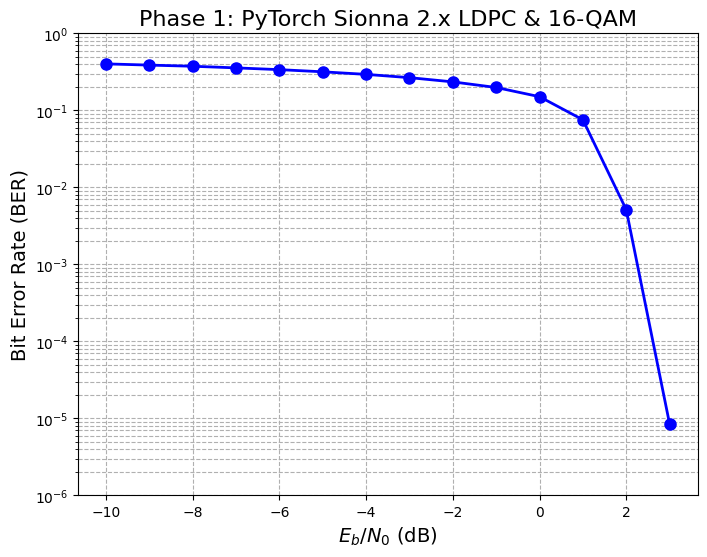

In [14]:
# ==========================================
# PLOT RESULTS
# ==========================================
plt.figure(figsize=(8, 6))
plt.semilogy(ebno_dbs, ber_results, 'bo-', linewidth=2, markersize=8)
plt.grid(True, which="both", ls="--")
plt.xlabel(r"$E_b/N_0$ (dB)", fontsize=14)
plt.ylabel("Bit Error Rate (BER)", fontsize=14)
plt.title("Phase 1: PyTorch Sionna 2.x LDPC & 16-QAM", fontsize=16)
plt.ylim([1e-6, 1])
plt.show()

## Phase - 2

In [16]:
## MIMO with dummy precoder over flat fading rayleigh channel with AWGN Noise

class Phase2MIMOPipeline(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.k = 490  
        self.n = 1024 
        self.num_bits_per_symbol = 4 # 16-QAM
        self.coderate = self.k / self.n
        
        # MIMO Spatial Parameters
        self.num_tx_ant = 32
        self.num_rx_ant = 4
        self.num_layers = 2
        
        self.encoder = sn_phy.fec.ldpc.LDPC5GEncoder(self.k, self.n)
        self.decoder = sn_phy.fec.ldpc.LDPC5GDecoder(self.encoder, num_iter=8, return_infobits=True)
        self.mapper = sn_phy.mapping.Mapper("qam", self.num_bits_per_symbol)
        self.demapper = sn_phy.mapping.Demapper("app", "qam", self.num_bits_per_symbol)

    def forward(self, batch_size, ebno_db, device):
        
        # -------------------------------------------
        # 1. Baseband Processing
        # -------------------------------------------
        b = torch.randint(0, 2, (batch_size, self.k), dtype=torch.float32, device=device)
        c = self.encoder(b)
        x = self.mapper(c) 
        
        # Split 256 symbols into 2 layers -> Shape: [batch_size, 128, 2, 1]
        num_symbols_per_layer = x.shape[1] // self.num_layers
        x_layers = x.view(batch_size, num_symbols_per_layer, self.num_layers, 1)

        # -------------------------------------------
        # 2. The Normalized Dummy Precoder (W)
        # -------------------------------------------
        W = torch.zeros((batch_size, 1, self.num_tx_ant, self.num_layers), dtype=torch.cfloat, device=device)
        W[:, :, 0, 0] = 1.0 + 0j 
        W[:, :, 1, 1] = 1.0 + 0j 
        
        # Enforce Base Station Power Budget (Total Energy = 1.0)
        W = W / np.sqrt(self.num_layers)
        
        s = torch.matmul(W, x_layers)

        # -------------------------------------------
        # 3. Flat Rayleigh Fading Channel (H) & Strict Noise Math
        # -------------------------------------------
        H = torch.randn((batch_size, 1, self.num_rx_ant, self.num_tx_ant), dtype=torch.cfloat, device=device)
        H = H / np.sqrt(2.0) # Channel variance is strictly 1.0
        
        # Exact Bit Energy Math based on 1.0 Transmit Power
        ebno_linear = 10.0 ** (ebno_db / 10.0)
        bits_total = self.num_layers * self.num_bits_per_symbol * self.coderate
        eb = 1.0 / bits_total
        no = eb / ebno_linear
        
        y_clean = torch.matmul(H, s)
        noise = torch.randn_like(y_clean) * np.sqrt(no / 2.0)
        y = y_clean + noise

        # -------------------------------------------
        # 4. Oracle MMSE Equalizer & Symbol Unbiasing
        # -------------------------------------------
        H_eff = torch.matmul(H, W)
        H_eff_H = H_eff.mH
        
        I = torch.eye(self.num_layers, dtype=torch.cfloat, device=device).view(1, 1, self.num_layers, self.num_layers)
        covariance = torch.matmul(H_eff_H, H_eff) + (no * I)
        G_mmse = torch.matmul(torch.linalg.inv(covariance), H_eff_H) 
        
        x_hat_biased = torch.matmul(G_mmse, y)
        
        # [FIX 3] Extract the effective channel diagonal (d_k) to unbias the symbols
        # D shape: [batch_size, 1, 2, 2] -> d_k shape: [batch_size, 1, 2, 1]
        D = torch.matmul(G_mmse, H_eff)
        d_k = torch.diagonal(D, dim1=-2, dim2=-1).unsqueeze(-1)
        
        # Unbias the symbols so the constellation grid aligns perfectly with the demapper
        x_hat_unbiased = x_hat_biased / d_k
        
        # Calculate Post-EQ SINR to find the true effective noise floor
        d_k_real = torch.clamp(d_k.real, min=1e-6, max=1.0 - 1e-6)
        sinr_k = d_k_real / (1.0 - d_k_real)
        no_eff = 1.0 / sinr_k # The true noise variance felt by the demapper

        # -------------------------------------------
        # 5. Demap and Decode
        # -------------------------------------------
        # Expand and flatten the effective noise tensor to match the symbol layout
        no_eff_expand = no_eff.expand(-1, num_symbols_per_layer, -1, -1).reshape(batch_size, -1)
        x_hat_flat = x_hat_unbiased.reshape(batch_size, -1)
        
        llr = self.demapper(x_hat_flat, no_eff_expand)
        b_hat = self.decoder(llr)
        
        return b, b_hat

# ==========================================
# KAGGLE EXECUTION BLOCK
# ==========================================
print("Initializing Phase 2 MIMO Simulator...")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing on: {device}")

model = Phase2MIMOPipeline().to(device)

ebno_dbs = np.arange(0, 14, 1.0) # Fading requires much higher SNR!
ber_results = []

batch_size = 5000 
target_errors = 350
max_batches = 200 # Your debug limit!

print("Running Monte Carlo batches...")

with torch.no_grad(): 
    for ebno_db in ebno_dbs:
        total_errors = 0
        total_bits = 0
        batches_run = 0
        
        while total_errors < target_errors and batches_run < max_batches:
            b, b_hat = model(batch_size, ebno_db, device)
            
            errors = torch.sum(b != b_hat).item()
            total_errors += errors
            total_bits += b.numel()
            batches_run += 1
            
        ber = total_errors / total_bits
        ber_results.append(ber)
        print(f"Eb/N0: {ebno_db:4.0f} dB | Errors: {total_errors:5.0f} | Bits: {total_bits:10.0f} | BER: {ber:.6e}")

Initializing Phase 2 MIMO Simulator...
Executing on: cuda
Running Monte Carlo batches...
Eb/N0:    0 dB | Errors: 191003 | Bits:    2450000 | BER: 7.796041e-02
Eb/N0:    1 dB | Errors: 111713 | Bits:    2450000 | BER: 4.559714e-02
Eb/N0:    2 dB | Errors: 61792 | Bits:    2450000 | BER: 2.522122e-02
Eb/N0:    3 dB | Errors: 28209 | Bits:    2450000 | BER: 1.151388e-02
Eb/N0:    4 dB | Errors: 16376 | Bits:    2450000 | BER: 6.684082e-03
Eb/N0:    5 dB | Errors:  7351 | Bits:    2450000 | BER: 3.000408e-03
Eb/N0:    6 dB | Errors:  4099 | Bits:    2450000 | BER: 1.673061e-03
Eb/N0:    7 dB | Errors:  1771 | Bits:    2450000 | BER: 7.228571e-04
Eb/N0:    8 dB | Errors:  1339 | Bits:    2450000 | BER: 5.465306e-04
Eb/N0:    9 dB | Errors:   538 | Bits:    4900000 | BER: 1.097959e-04
Eb/N0:   10 dB | Errors:   359 | Bits:    4900000 | BER: 7.326531e-05
Eb/N0:   11 dB | Errors:   436 | Bits:    7350000 | BER: 5.931973e-05
Eb/N0:   12 dB | Errors:   355 | Bits:   22050000 | BER: 1.609977e-05

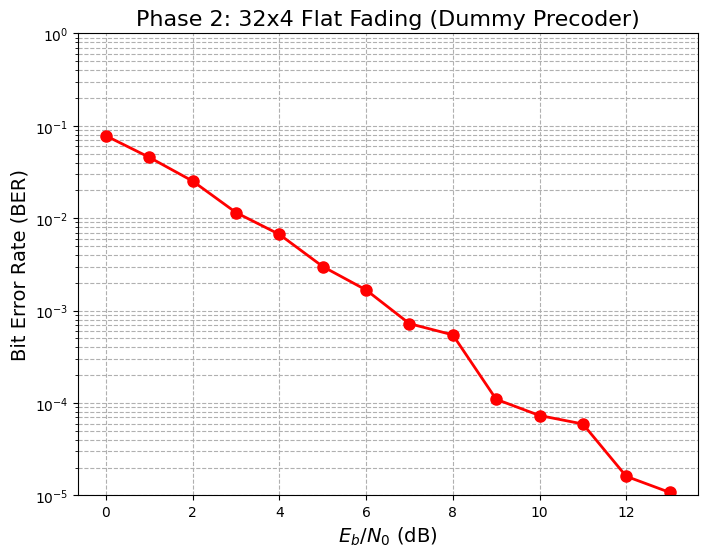

In [17]:
# ==========================================
# PLOT RESULTS
# ==========================================
plt.figure(figsize=(8, 6))
plt.semilogy(ebno_dbs, ber_results, 'ro-', linewidth=2, markersize=8)
plt.grid(True, which="both", ls="--")
plt.xlabel(r"$E_b/N_0$ (dB)", fontsize=14)
plt.ylabel("Bit Error Rate (BER)", fontsize=14)
plt.title("Phase 2: 32x4 Flat Fading (Dummy Precoder)", fontsize=16)
plt.ylim([1e-5, 1])
plt.show()

## Phase 3

In [22]:
def build_polarized_path_g(H):
    """Constructs a 4x32 channel path with 3GPP 38.901 Polarization Matrix"""
    
    # 1. Extract the raw spatial steering matrix (2 Rx spatial x 16 Tx spatial)
    # We slice out just Pol 1 since the physical element locations are identical
    # 3GPP Standard Urban Micro XPR is typically 8 dB
    xpr_db = 8.0 
    kappa = 10.0 ** (-xpr_db / 10.0) 
    
    # Normalization factor so the total energy still equals p_los / p_nlos
    # The matrix energy is (1 + kappa + kappa + 1) = 2 + 2*kappa
    norm_factor = np.sqrt(1.0 / (2.0 + 2.0 * kappa))
    
    H_spatial = H[:,0:2,0:16] # Shape: [Batch, 2, 16]
    
    # 2. Generate 4 independent random phases (0 to 2pi)
    phi_11 = torch.empty(batch_size, 1, 1, device=device).uniform_(0, 2 * np.pi)
    phi_12 = torch.empty(batch_size, 1, 1, device=device).uniform_(0, 2 * np.pi)
    phi_21 = torch.empty(batch_size, 1, 1, device=device).uniform_(0, 2 * np.pi)
    phi_22 = torch.empty(batch_size, 1, 1, device=device).uniform_(0, 2 * np.pi)
    
    # 3. Create the 4 block matrices with phase and XPD leakage
    H_11 = torch.exp(1j * phi_11) * H_spatial
    H_12 = np.sqrt(kappa) * torch.exp(1j * phi_12) * H_spatial
    H_21 = np.sqrt(kappa) * torch.exp(1j * phi_21) * H_spatial
    H_22 = torch.exp(1j * phi_22) * H_spatial
    
    # 4. Stitch the blocks back into the full 4x32 matrix
    H_top = torch.cat([H_11, H_12], dim=2)       # Shape: [Batch, 2, 32]
    H_bottom = torch.cat([H_21, H_22], dim=2)    # Shape: [Batch, 2, 32]
    H_full = torch.cat([H_top, H_bottom], dim=1) # Shape: [Batch, 4, 32]
    
    # 5. Apply the path power and polarization normalizer
    return norm_factor * H_full

In [27]:
## MIMO with SVD/3gpp precoding on flat fading rayleigh channel
class Phase3PrecoderPipeline(nn.Module):
    # [FIX 3] Added eps15_mask_np to initialization
    def __init__(self, w_codebook_np, hpbw_mask_np, eps15_mask_np):
        super().__init__()
        
        self.k = 490  
        self.n = 1024 
        self.num_bits_per_symbol = 4 # 16-QAM
        self.coderate = self.k / self.n
        
        self.num_tx_ant = 32
        self.num_rx_ant = 4
        self.num_layers = 2
        
        self.encoder = sn_phy.fec.ldpc.LDPC5GEncoder(self.k, self.n)
        self.decoder = sn_phy.fec.ldpc.LDPC5GDecoder(self.encoder, num_iter=8, return_infobits=True)
        self.mapper = sn_phy.mapping.Mapper("qam", self.num_bits_per_symbol)
        self.demapper = sn_phy.mapping.Demapper("app", "qam", self.num_bits_per_symbol)

        self.num_pms = 2048
        
        W_tensor = torch.tensor(np.array(w_codebook_np), dtype=torch.cfloat)
        self.W_codebook = nn.Parameter(W_tensor, requires_grad=False)
        
        self.hpbw_mask = nn.Parameter(torch.tensor(hpbw_mask_np, dtype=torch.bool), requires_grad=False)
        self.eps15_mask = nn.Parameter(torch.tensor(eps15_mask_np, dtype=torch.bool), requires_grad=False)

    def forward(self, batch_size, ebno_db, strategy, device):
        # 1. Baseband (Bits -> QAM -> Layers)
        b = torch.randint(0, 2, (batch_size, self.k), dtype=torch.float32, device=device)
        c = self.encoder(b)
        x = self.mapper(c)
        num_symbols_per_layer = x.shape[1] // self.num_layers
        x_layers = x.view(batch_size, num_symbols_per_layer, self.num_layers, 1)

        # Generate Flat Rayleigh Channel
        H = torch.randn((batch_size, self.num_rx_ant, self.num_tx_ant), dtype=torch.cfloat, device=device)
        H = H / np.sqrt(2.0)

        
        H = build_polarized_path_g(H)
            

        # [FIX 1] Strict Eb/N0 Math
        ebno_linear = 10.0 ** (ebno_db / 10.0)
        bits_total = self.num_layers * self.num_bits_per_symbol * self.coderate
        eb = 1.0 / bits_total
        no = eb / ebno_linear

        # -------------------------------------------
        # 2. INTELLIGENT PRECODER SELECTION
        # -------------------------------------------
        if strategy == "SVD":
            _, _, Vh = torch.linalg.svd(H.cpu(), full_matrices=False)
            Vh = Vh.to(device)
            V = Vh.mH 
            W_opt = V[:, :, :self.num_layers]
            W_opt = W_opt / np.sqrt(self.num_layers) 
            
        elif strategy.startswith("3GPP"):
            H_eff_all = torch.einsum('b r t, k t l -> b k r l', H, self.W_codebook)
            H_eff_H = H_eff_all.mH
            I = torch.eye(self.num_layers, dtype=torch.cfloat, device=device).view(1, 1, self.num_layers, self.num_layers)
            
            R = torch.matmul(H_eff_H, H_eff_all) + (no * I)
            E = torch.linalg.inv(R)
            
            E_diag = torch.diagonal(E, dim1=-2, dim2=-1).real
            SINR = (1.0 / (no * E_diag)) - 1.0
            
            Capacity = torch.sum(torch.log2(1.0 + torch.clamp(SINR, min=0)), dim=-1) 
            
            # [FIX 3] Implement both masking strategies
            if strategy == "3GPP_HPBW":
                Capacity[:, ~self.hpbw_mask] = -float('inf')
            elif strategy == "3GPP_EPS15":
                Capacity[:, ~self.eps15_mask] = -float('inf')
                
            best_pmi_indices = torch.argmax(Capacity, dim=-1) 
            W_opt = self.W_codebook[best_pmi_indices] / np.sqrt(self.num_layers)  # normalize , W is normalized per layer
            # But not normalized for total energy

        # -------------------------------------------
        # 3. Transmit, Channel, Receive
        # -------------------------------------------
        W_expanded = W_opt.unsqueeze(1) # Shape: [Batch, 1, 32, 2]
        H_expanded = H.unsqueeze(1)     # Shape: [Batch, 1, 4, 32]
        
        s = torch.matmul(W_expanded, x_layers)
        y_clean = torch.matmul(H_expanded, s)
        
        noise_tensor = torch.randn_like(y_clean) * np.sqrt(no / 2.0)
        y = y_clean + noise_tensor

        # -------------------------------------------
        # 4. MMSE Equalizer & Symbol Unbiasing
        # -------------------------------------------
        H_eff = torch.matmul(H_expanded, W_expanded)
        H_eff_H = H_eff.mH
        I_eq = torch.eye(self.num_layers, dtype=torch.cfloat, device=device).view(1, 1, self.num_layers, self.num_layers)
        
        covariance_eq = torch.matmul(H_eff_H, H_eff) + (no * I_eq)
        G_mmse = torch.matmul(torch.linalg.inv(covariance_eq), H_eff_H) 
        
        x_hat_biased = torch.matmul(G_mmse, y)
        
        # [FIX 2] Extract diagonal, unbias, and calculate true N_eff
        D = torch.matmul(G_mmse, H_eff)
        d_k = torch.diagonal(D, dim1=-2, dim2=-1).unsqueeze(-1)
        
        x_hat_unbiased = x_hat_biased / d_k
        
        d_k_real = torch.clamp(d_k.real, min=1e-6, max=1.0 - 1e-6)
        sinr_k = d_k_real / (1.0 - d_k_real)
        no_eff = 1.0 / sinr_k 
        
        # 5. Demap & Decode
        no_eff_expand = no_eff.expand(-1, num_symbols_per_layer, -1, -1).reshape(batch_size, -1)
        x_hat_flat = x_hat_unbiased.reshape(batch_size, -1)
        
        llr = self.demapper(x_hat_flat, no_eff_expand)
        b_hat = self.decoder(llr)
        
        return b, b_hat


# ==========================================
# EXECUTION SCRIPT
# ==========================================
print("Initializing Phase 3 Precoder Simulator...")

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Executing on: {device}")

# Assuming W_codebook, hpbw_survivor_mask, and eps_15_survivor_mask are in memory
model = Phase3PrecoderPipeline(W_codebook, hpbw_survivor_mask, eps_15_survivor_mask).to(device)

ebno_dbs = np.arange(-15.0, 10.0, 0.5) 
strategies = ["SVD", "3GPP_ALL", "3GPP_HPBW", "3GPP_EPS15"]

results = {s: [] for s in strategies}
snrs = {s: [] for s in strategies}

batch_size = 500 
target_errors = 1000 
max_batches = 150
ber_tripwire = 1e-4

for strategy in strategies:
    print(f"\n--- Running Precoding Strategy: {strategy} ---")
    for ebno_db in ebno_dbs:
        total_errors = 0
        total_bits = 0
        batches_run = 0
        
        with torch.no_grad(): 
            while total_errors < target_errors and batches_run < max_batches:
                b, b_hat = model(batch_size, ebno_db, strategy, device)
                errors = torch.sum(b != b_hat).item()
                total_errors += errors
                total_bits += b.numel()
                batches_run += 1
                
        ber = total_errors / total_bits
        results[strategy].append(ber)
        snrs[strategy].append(ebno_db)
        
        print(f"Eb/N0: {ebno_db:4.1f} dB | Errors: {total_errors:5.0f} | Bits: {total_bits:9.0f} | BER: {ber:.6e}")
        
        # Fast-Forward / Tripwire
        if ber < ber_tripwire:
            print(f"  -> [TRIPWIRE ACTIVATED] BER dropped below {ber_tripwire}. Moving to next strategy.")
            break
            
    torch.cuda.empty_cache()
    gc.collect()

Initializing Phase 3 Precoder Simulator...
Executing on: cuda:0

--- Running Precoding Strategy: SVD ---
Eb/N0: -15.0 dB | Errors: 88833 | Bits:    245000 | BER: 3.625837e-01
Eb/N0: -14.5 dB | Errors: 87431 | Bits:    245000 | BER: 3.568612e-01
Eb/N0: -14.0 dB | Errors: 84911 | Bits:    245000 | BER: 3.465755e-01
Eb/N0: -13.5 dB | Errors: 82894 | Bits:    245000 | BER: 3.383429e-01
Eb/N0: -13.0 dB | Errors: 79995 | Bits:    245000 | BER: 3.265102e-01
Eb/N0: -12.5 dB | Errors: 77167 | Bits:    245000 | BER: 3.149673e-01
Eb/N0: -12.0 dB | Errors: 75108 | Bits:    245000 | BER: 3.065633e-01
Eb/N0: -11.5 dB | Errors: 71471 | Bits:    245000 | BER: 2.917184e-01
Eb/N0: -11.0 dB | Errors: 68914 | Bits:    245000 | BER: 2.812816e-01
Eb/N0: -10.5 dB | Errors: 65301 | Bits:    245000 | BER: 2.665347e-01
Eb/N0: -10.0 dB | Errors: 60612 | Bits:    245000 | BER: 2.473959e-01
Eb/N0: -9.5 dB | Errors: 56474 | Bits:    245000 | BER: 2.305061e-01
Eb/N0: -9.0 dB | Errors: 52294 | Bits:    245000 | BER: 

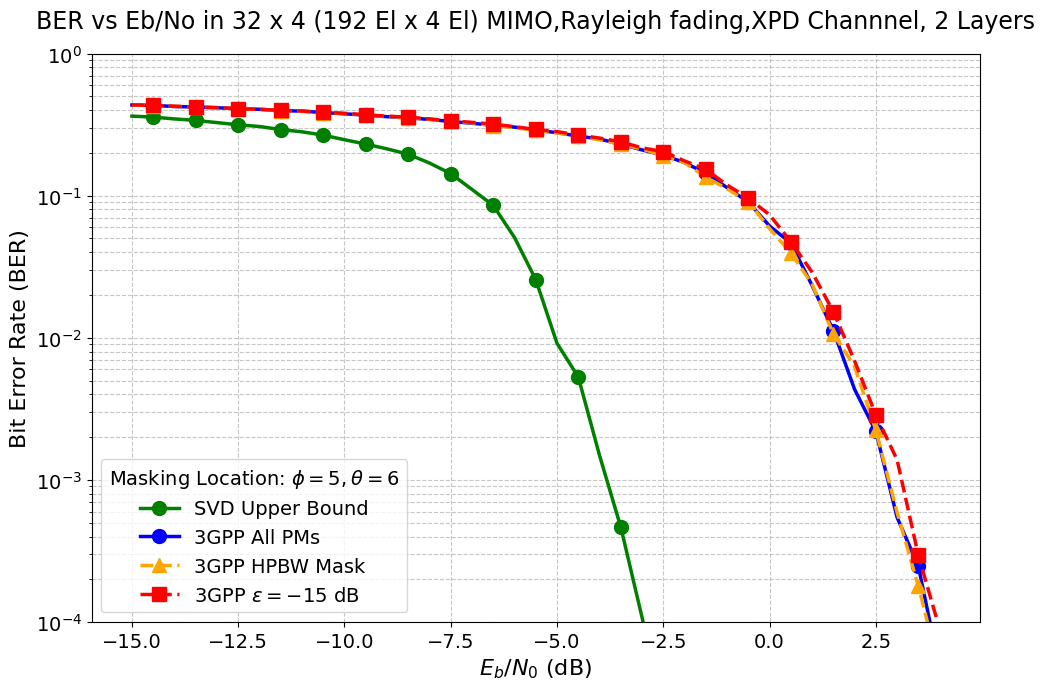

In [55]:
# ==========================================
# PLOTTING
# ==========================================
plt.figure(figsize=(10, 7))

colors = {'SVD': 'green', '3GPP_ALL': 'blue', '3GPP_HPBW': 'orange', '3GPP_EPS15': 'red'}
markers = {'SVD': 'o', '3GPP_ALL': 'o', '3GPP_HPBW': '^', '3GPP_EPS15': 's'}
lines = {'SVD': '-', '3GPP_ALL': '-', '3GPP_HPBW': '--', '3GPP_EPS15': '--'}
labels = {'SVD': 'SVD Upper Bound', '3GPP_ALL': '3GPP All PMs', '3GPP_HPBW': r'3GPP HPBW Mask', '3GPP_EPS15': r'3GPP $\epsilon = -15$ dB'}

for strategy in strategies:
    if len(snrs[strategy]) > 0:
        plt.semilogy(snrs[strategy], results[strategy], 
                     color=colors[strategy], linestyle=lines[strategy], 
                     marker=markers[strategy],markevery=(1, 2),
                     linewidth=2.5, markersize=10, 
                     label=labels[strategy])

plt.title("BER vs Eb/No in 32 x 4 (192 El x 4 El) MIMO,Rayleigh fading,XPD Channnel, 2 Layers", fontsize=17,y=1.03)
plt.xlabel(r"$E_b/N_0$ (dB)", fontsize=16)
plt.ylabel("Bit Error Rate (BER)", fontsize=16)
plt.grid(True, which="both", linestyle="--", alpha=0.7)
plt.ylim([1e-4, 1])
plt.legend(fontsize=14,title=r'Masking Location: $\phi=5,\theta=6$',loc='lower left',title_fontsize=14)
plt.xticks(fontsize=14) 
plt.yticks(fontsize=14) 
plt.tight_layout()
#plt.savefig("Rayleigh_1.pdf", bbox_inches="tight",dpi=300)
plt.show()

## Phase 3.5 - LOS+NLOS Channel Creation

In [18]:
'''
def generate_hardware_layout():
    """
    Generates the physical (y, z) coordinates for 192 elements and the analog mapping.
    Assumes a standard panel: ## Wrong? 12 rows x 8 cols = 96 physical locations.
    Dual polarization = 192 total radiating elements.
    Mapped to a 4x4 Dual-Pol logical grid (32 ports).
    """
    num_rows_phys = 8
    num_cols_phys = 12
    num_rows_logical = 4
    num_cols_logical = 4
    
    # Standard spacing (can be tweaked!)
    dh = 0.5 * lam 
    dv = 0.8 * lam 
    
    y_coords = []
    z_coords = []
    
    # 1. Generate Coordinates (96 locations x 2 pols)
    for pol in range(2):
        for col in range(num_cols_phys):
            for row in range(num_rows_phys):
                y_coords.append(col * dh)
                z_coords.append(row * dv)
                
    y_coords = np.array(y_coords)
    z_coords = np.array(z_coords)
    
    # 2. Generate Analog Wiring Matrix (M_analog)
    # 192 elements down to 32 ports
    M_analog = np.zeros((192, 32), dtype=complex)
    
    rows_per_subarray = num_rows_phys // num_rows_logical # 12 / 4 = 3
    cols_per_subarray = num_cols_phys // num_cols_logical # 8 / 4 = 2
    elements_per_subarray = rows_per_subarray * cols_per_subarray # 6
    
    # Map each physical element to its logical port
    for i in range(192):
        pol = i // 96
        idx_in_pol = i % 96
        col = idx_in_pol // num_rows_phys
        row = idx_in_pol % num_rows_phys
        
        logical_col = col // cols_per_subarray
        logical_row = row // rows_per_subarray
        
        port_idx = pol * 16 + (logical_col * 4) + logical_row
        
        # Wiring weight (normalized by number of elements in subarray)
        M_analog[i, port_idx] = 1.0 / np.sqrt(elements_per_subarray)
        
    return y_coords, z_coords, torch.tensor(M_analog)

y_coords, z_coords, M_analog = generate_hardware_layout()
'''

'\ndef generate_hardware_layout():\n    """\n    Generates the physical (y, z) coordinates for 192 elements and the analog mapping.\n    Assumes a standard panel: ## Wrong? 12 rows x 8 cols = 96 physical locations.\n    Dual polarization = 192 total radiating elements.\n    Mapped to a 4x4 Dual-Pol logical grid (32 ports).\n    """\n    num_rows_phys = 8\n    num_cols_phys = 12\n    num_rows_logical = 4\n    num_cols_logical = 4\n    \n    # Standard spacing (can be tweaked!)\n    dh = 0.5 * lam \n    dv = 0.8 * lam \n    \n    y_coords = []\n    z_coords = []\n    \n    # 1. Generate Coordinates (96 locations x 2 pols)\n    for pol in range(2):\n        for col in range(num_cols_phys):\n            for row in range(num_rows_phys):\n                y_coords.append(col * dh)\n                z_coords.append(row * dv)\n                \n    y_coords = np.array(y_coords)\n    z_coords = np.array(z_coords)\n    \n    # 2. Generate Analog Wiring Matrix (M_analog)\n    # 192 elements down to

In [19]:
print("Initializing Deterministic True-Hardware Channel...")
device = torch.device("cpu") 

# ------------------------------------------------
# 0. HARDWARE SETUP (192 Elements -> 32 Ports)
# ------------------------------------------------
fc = 3.75e9
c = 3e8
lam = c / fc
k = 2 * np.pi / lam

y_coords, z_coords, M_analog_tensor = y_coords,z_coords,torch.tensor(M_analog)

# ------------------------------------------------
# 1. STEERING VECTOR FUNCTIONS
# ------------------------------------------------
def get_true_hardware_steering_vector(y, z, M, az_deg, zenith_deg):
    """
    Transmitter: Uses exact (y,z) coordinates and M_analog wiring.
    """
    az_rad = az_deg * (np.pi / 180.0)
    zenith_rad = zenith_deg * (np.pi / 180.0)
    
    # Phase for all 192 physical elements
    phase = k * (y * np.sin(zenith_rad) * np.sin(az_rad) + z * np.cos(zenith_rad))
    a_elem = torch.exp(-1j * torch.tensor(phase, dtype=torch.float64)).view(-1, 1).to(torch.cfloat)
    
    # Pass through analog hardware to get the 32 port signatures
    a_port = torch.matmul(M.mH.to(torch.complex64) , a_elem.to(torch.complex64))
    
    # Normalize
    return a_port / torch.norm(a_port)

def get_ura_steering_vector(num_rows, num_cols, az_deg, el_deg):
    """
    Receiver: Simplified lambda/2 math for the UE.
    """
    az_rad = az_deg * (np.pi / 180.0)
    el_rad = el_deg * (np.pi / 180.0)
    m = torch.arange(num_rows).view(num_rows, 1)
    n = torch.arange(num_cols).view(1, num_cols)
    phase = np.pi * (m * np.cos(el_rad) + n * np.sin(el_rad) * np.sin(az_rad))
    steering_1d = torch.exp(-1j * phase).flatten()
    steering_dual = torch.cat([steering_1d, steering_1d], dim=0).view(-1, 1)
    return steering_dual / np.sqrt(num_rows * num_cols * 2)

# ------------------------------------------------
# 2. DEFINE THE PHYSICAL SCENARIO
# ------------------------------------------------
los_az_tx = 15.0
los_el_tx = 90.0  
los_power = 1.0   
los_phase = 0.0   

nlos_az_tx = 50.0
nlos_el_tx = 100.0
nlos_power = 0.25 
nlos_phase = np.pi * 0.65 

# ------------------------------------------------
# 3. BUILD THE H MATRIX (HARDWARE AWARE)
# ------------------------------------------------
# A. Base Station Transmit Vectors (HARDWARE FUNCTION)
a_tx_los = get_true_hardware_steering_vector(y_coords, z_coords, M_analog_tensor, los_az_tx, los_el_tx)
a_tx_nlos = get_true_hardware_steering_vector(y_coords, z_coords, M_analog_tensor, nlos_az_tx, nlos_el_tx)

# B. UE Receive Vectors (SIMPLE FUNCTION)
a_rx_los = get_ura_steering_vector(1, 2, 0.0, 90.0)    
a_rx_nlos = get_ura_steering_vector(1, 2, 60.0, 90.0) 

# C. Calculate Path Gains
alpha_los = np.sqrt(los_power) * np.exp(1j * los_phase)
alpha_nlos = np.sqrt(nlos_power) * np.exp(1j * nlos_phase)

# D. Sum the rays: [4, 1] @ [1, 32] -> [4, 32]
H_los = alpha_los * torch.matmul(a_rx_los, a_tx_los.mH)
H_nlos = alpha_nlos * torch.matmul(a_rx_nlos, a_tx_nlos.mH)
H = H_los + H_nlos

# ------------------------------------------------
# 4. EXTRACT OPTIMAL BEAMS (SVD)
# ------------------------------------------------
U, S, Vh = torch.linalg.svd(H)
V = Vh.mH
v1 = V[:, 0].resolve_conj().numpy()
v2 = V[:, 1].resolve_conj().numpy()

print(f"Singular Values of Hardware Channel:")
print(f"S1: {S[0]:.4f}")
print(f"S2: {S[1]:.4f}")

# ------------------------------------------------
# 5. VISUALIZE THE HARDWARE BEAMFORMING RESPONSE 
# ------------------------------------------------
az_res, el_res = 361, 181 

scan_az = np.linspace(-180, 180, az_res) 
math_zenith = np.linspace(0, 180, el_res) 
plot_el = 90 - math_zenith 
AZ, EL_MATH = np.meshgrid(scan_az * np.pi/180, math_zenith * np.pi/180)

# A. Calculate spatial phase for all 192 elements across the entire grid
# We use numpy broadcasting: y_coords [192, 1, 1] * EL_MATH [181, 361]
phase_scan = k * (y_coords[:, None, None] * np.sin(EL_MATH) * np.sin(AZ) + 
                  z_coords[:, None, None] * np.cos(EL_MATH))

# Shape: [192, 181, 361]
a_elem_scan = np.exp(-1j * phase_scan)

# B. Flatten the spatial grid
# Shape: [192, 65341]
a_elem_flat = a_elem_scan.reshape(192, -1)

# C. Pass the scanning grid through the analog hardware!
# [32, 192] @ [192, 65341] -> [32, 65341]
M_analog_np = M_analog
a_port_flat = M_analog_np.conj().T @ a_elem_flat

# Normalize the columns so each spatial angle has unit energy
norms = np.linalg.norm(a_port_flat, axis=0, keepdims=True)
S_matrix = a_port_flat / (norms + 1e-12)

# D. Perform the Batch Projection against v1 and v2
# [65341, 32] @ [32] -> [65341]
beam_pattern_v1_flat = np.abs(np.conj(S_matrix).T @ v1)**2
beam_pattern_v2_flat = np.abs(np.conj(S_matrix).T @ v2)**2

beam_pattern_v1 = beam_pattern_v1_flat.reshape(el_res, az_res)
beam_pattern_v2 = beam_pattern_v2_flat.reshape(el_res, az_res)

beam_pattern_v1_db = 10 * np.log10(beam_pattern_v1 + 1e-10)
beam_pattern_v2_db = 10 * np.log10(beam_pattern_v2 + 1e-10)

Initializing Deterministic True-Hardware Channel...
Singular Values of Hardware Channel:
S1: 1.0069
S2: 0.4856


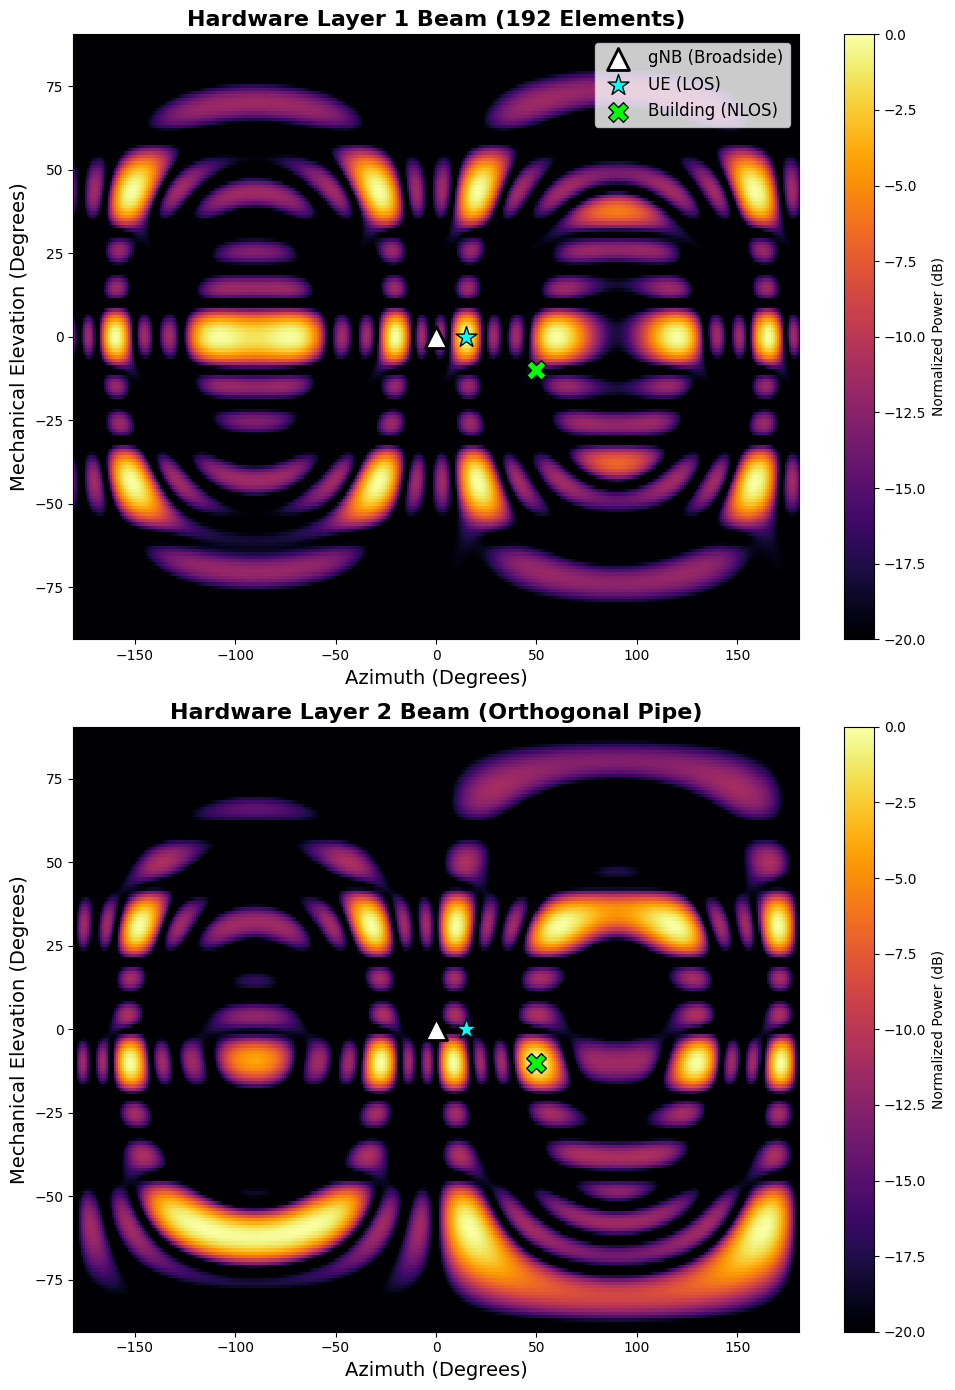

In [20]:
# ==========================================================
# PLOTTING
# ==========================================================
fig, axes = plt.subplots(2, 1, figsize=(10, 14))

# Plot 1
c1 = axes[0].pcolormesh(scan_az, plot_el, beam_pattern_v1_db, shading='auto', cmap='inferno', vmin=-20, vmax=0)
axes[0].scatter(0, 0, c='white', marker='^', s=250, edgecolors='black', linewidth=2, label='gNB (Broadside)')
axes[0].scatter(los_az_tx, 90 - los_el_tx, c='cyan', marker='*', s=250, edgecolors='black', label='UE (LOS)')
axes[0].scatter(nlos_az_tx, 90 - nlos_el_tx, c='lime', marker='X', s=200, edgecolors='black', label='Building (NLOS)')
axes[0].set_title("Hardware Layer 1 Beam (192 Elements)", fontsize=16, fontweight='bold')
axes[0].set_xlabel("Azimuth (Degrees)", fontsize=14)
axes[0].set_ylabel("Mechanical Elevation (Degrees)", fontsize=14)
axes[0].legend(loc='upper right', fontsize=12)
fig.colorbar(c1, ax=axes[0], label="Normalized Power (dB)")

# Plot 2
c2 = axes[1].pcolormesh(scan_az, plot_el, beam_pattern_v2_db, shading='auto', cmap='inferno', vmin=-20, vmax=0)
axes[1].scatter(0, 0, c='white', marker='^', s=250, edgecolors='black', linewidth=2)
axes[1].scatter(los_az_tx, 90 - los_el_tx, c='cyan', marker='*', s=250, edgecolors='black')
axes[1].scatter(nlos_az_tx, 90 - nlos_el_tx, c='lime', marker='X', s=200, edgecolors='black')
axes[1].set_title("Hardware Layer 2 Beam (Orthogonal Pipe)", fontsize=16, fontweight='bold')
axes[1].set_xlabel("Azimuth (Degrees)", fontsize=14)
axes[1].set_ylabel("Mechanical Elevation (Degrees)", fontsize=14)
fig.colorbar(c2, ax=axes[1], label="Normalized Power (dB)")

plt.tight_layout()
plt.show()

In [21]:
print("Generating 3D Interactive Radiation Patterns (Including Total EIRP)...")

# 1. Setup the 3D Math parameters
vmin_val = -20.0 
stride = 2       

# --- MATH: TOTAL EIRP ---
# The precoder divides the 1.0 power budget equally across the 2 layers
total_power_flat = 0.5 * beam_pattern_v1_flat + 0.5 * beam_pattern_v2_flat
total_power = total_power_flat.reshape(el_res, az_res)
total_power_db = 10 * np.log10(total_power + 1e-12) # Add epsilon to prevent log(0)

# --- SURFACE 1: LAYER 1 ---
beam_v1_clipped = np.clip(beam_pattern_v1_db, vmin_val, 0)
r_v1 = beam_v1_clipped - vmin_val
X_v1 = r_v1 * np.sin(EL_MATH) * np.cos(AZ)
Y_v1 = r_v1 * np.sin(EL_MATH) * np.sin(AZ)
Z_v1 = r_v1 * np.cos(EL_MATH)

# --- SURFACE 2: LAYER 2 ---
beam_v2_clipped = np.clip(beam_pattern_v2_db, vmin_val, 0)
r_v2 = beam_v2_clipped - vmin_val
X_v2 = r_v2 * np.sin(EL_MATH) * np.cos(AZ)
Y_v2 = r_v2 * np.sin(EL_MATH) * np.sin(AZ)
Z_v2 = r_v2 * np.cos(EL_MATH)

# --- SURFACE 3: TOTAL EIRP ---
total_clipped = np.clip(total_power_db, vmin_val, 0)
r_tot = total_clipped - vmin_val
X_tot = r_tot * np.sin(EL_MATH) * np.cos(AZ)
Y_tot = r_tot * np.sin(EL_MATH) * np.sin(AZ)
Z_tot = r_tot * np.cos(EL_MATH)

# 2. Map the Physical Targets
target_radius = abs(vmin_val)

# Target 1: UE (LOS Path)
ue_az_rad = los_az_tx * (np.pi / 180.0)
ue_zenith_rad = los_el_tx * (np.pi / 180.0) 
X_ue = target_radius * np.sin(ue_zenith_rad) * np.cos(ue_az_rad)
Y_ue = target_radius * np.sin(ue_zenith_rad) * np.sin(ue_az_rad)
Z_ue = target_radius * np.cos(ue_zenith_rad)

# Target 2: Building (Reflection Path)
bldg_az_rad = nlos_az_tx * (np.pi / 180.0)
bldg_zenith_rad = nlos_el_tx * (np.pi / 180.0)
X_bldg = target_radius * np.sin(bldg_zenith_rad) * np.cos(bldg_az_rad)
Y_bldg = target_radius * np.sin(bldg_zenith_rad) * np.sin(bldg_az_rad)
Z_bldg = target_radius * np.cos(bldg_zenith_rad)

# 3. Build the Plotly Dashboard (1 Row, 3 Columns)
fig = make_subplots(
    rows=1, cols=3,
    specs=[[{"type": "surface"}, {"type": "surface"}, {"type": "surface"}]],
    subplot_titles=('Layer 1: Spatial Harvester', 'Layer 2: Orthogonal Pipe', 'Total EIRP: Overall Footprint')
)

# Common target marker dictionaries
marker_ue = dict(size=6, color='cyan', symbol='diamond', line=dict(color='black', width=1))
marker_bldg = dict(size=6, color='lime', symbol='x', line=dict(color='black', width=1))

# --- ADD TRACES: LAYER 1 ---
fig.add_trace(go.Surface(x=X_v1[::stride, ::stride], y=Y_v1[::stride, ::stride], z=Z_v1[::stride, ::stride],
                         surfacecolor=beam_v1_clipped[::stride, ::stride], colorscale='Inferno', 
                         cmin=vmin_val, cmax=0, showscale=False), row=1, col=1)
fig.add_trace(go.Scatter3d(x=[X_ue], y=[Y_ue], z=[Z_ue], mode='markers', marker=marker_ue, name="UE (LOS)"), row=1, col=1)
fig.add_trace(go.Scatter3d(x=[X_bldg], y=[Y_bldg], z=[Z_bldg], mode='markers', marker=marker_bldg, name="Building"), row=1, col=1)

# --- ADD TRACES: LAYER 2 ---
fig.add_trace(go.Surface(x=X_v2[::stride, ::stride], y=Y_v2[::stride, ::stride], z=Z_v2[::stride, ::stride],
                         surfacecolor=beam_v2_clipped[::stride, ::stride], colorscale='Inferno', 
                         cmin=vmin_val, cmax=0, showscale=False), row=1, col=2)
fig.add_trace(go.Scatter3d(x=[X_ue], y=[Y_ue], z=[Z_ue], mode='markers', marker=marker_ue, showlegend=False), row=1, col=2)
fig.add_trace(go.Scatter3d(x=[X_bldg], y=[Y_bldg], z=[Z_bldg], mode='markers', marker=marker_bldg, showlegend=False), row=1, col=2)

# --- ADD TRACES: TOTAL EIRP ---
fig.add_trace(go.Surface(x=X_tot[::stride, ::stride], y=Y_tot[::stride, ::stride], z=Z_tot[::stride, ::stride],
                         surfacecolor=total_clipped[::stride, ::stride], colorscale='Inferno', 
                         cmin=vmin_val, cmax=0, colorbar=dict(title="Gain (dB)", len=0.75, x=1.05)), row=1, col=3)
fig.add_trace(go.Scatter3d(x=[X_ue], y=[Y_ue], z=[Z_ue], mode='markers', marker=marker_ue, showlegend=False), row=1, col=3)
fig.add_trace(go.Scatter3d(x=[X_bldg], y=[Y_bldg], z=[Z_bldg], mode='markers', marker=marker_bldg, showlegend=False), row=1, col=3)

# 4. Clean up the Layout
fig.update_layout(
    title_text="Phase 3.5: 3D True-Hardware Spatial Multiplexing",
    title_x=0.5,
    title_font_size=20,
    width=1600, height=600, # Widened to fit 3 columns cleanly
    margin=dict(l=10, r=10, b=10, t=60)
)

# Apply transparent backgrounds to all 3D scenes
for i in range(1, 4):
    fig.layout[f'scene{i if i > 1 else ""}'] = dict(
        xaxis=dict(showbackground=False, visible=False),
        yaxis=dict(showbackground=False, visible=False),
        zaxis=dict(showbackground=False, visible=False),
        camera=dict(eye=dict(x=1.5, y=-1.5, z=0.5))
    )

fig.show()

Generating 3D Interactive Radiation Patterns (Including Total EIRP)...


In [22]:
# Physical Constants
fc = 3.75e9 ## 3.75 or 5
c = 3e8
lam = c / fc
k_wave = 2 * np.pi / lam

def generate_stochastic_hardware_channel(batch_size, y_coords, z_coords, M_analog, device):
    """
    Generates a batch of normalized 4x32 stochastic geometric MIMO channels.
    Includes the true 192-element hardware mapping for the Base Station.
    """
    # ------------------------------------------------
    # 1. GENERATE RANDOM PARAMETERS (Batch-wise)
    # ------------------------------------------------
    # --- Tx Angles (Base Station) ---
    # LOS: Users randomly distributed in a 120-degree sector (-60 to +60)
    # Zenith: Users distributed from the horizon (90) down to the ground (100)
    '''
    # --- Tx Angles (Base Station) ---
    # PATH 1: Locked directly in the Danger Zone (Radar at 5, 84)
    tx_los_az = torch.full((batch_size,), 5.0, device=device)
    tx_los_zenith = torch.full((batch_size,), 84.0, device=device)
    
    # PATH 2: Tightly clustered, exactly ONE orthogonal codebook step away
    az_beam_step = float(np.degrees(np.arcsin(4 * 0.08 / (16 * 0.132)))) # ~8.7 degrees
    tx_nlos_az = tx_los_az + az_beam_step 
    tx_nlos_zenith = torch.full((batch_size,), 84.0, device=device)
    '''

    tx_los_az = torch.empty(batch_size, device=device).uniform_(3, 7)
    tx_los_zenith = torch.empty(batch_size, device=device).uniform_(80.0, 88.0) 

    az_offset_mag = torch.empty(batch_size, device=device).uniform_(5.0, 60.0)
    az_sign = torch.sign(torch.randn(batch_size, device=device)) 
    tx_nlos_az = tx_los_az + (az_offset_mag * az_sign)
    tx_nlos_zenith = torch.empty(batch_size, device=device).uniform_(80.0, 100)
    
    '''
    # --- Rx Angles (UE) ---
    # Keep wide separation at the UE to prevent flat fading phase collisions 
    # and guarantee the MMSE can perfectly demultiplex the layers.
    rx_los_az = torch.full((batch_size,), -45.0, device=device)
    rx_los_zenith = torch.full((batch_size,), 90.0, device=device)
    
    rx_nlos_az = torch.full((batch_size,), 45.0, device=device)
    rx_nlos_zenith = torch.full((batch_size,), 90.0, device=device)
    '''

    # --- Rx Angles (UE) ---
    # We assume the user's phone is pointing generally toward the tower (-30 to 30)
    rx_los_az = torch.empty(batch_size, device=device).uniform_(-30.0, 30.0)
    rx_los_zenith = torch.empty(batch_size, device=device).uniform_(80.0, 100.0)
    
    # The reflection hits the phone from a random wide angle
    rx_nlos_az = torch.empty(batch_size, device=device).uniform_(-180.0, 180.0)
    rx_nlos_zenith = torch.empty(batch_size, device=device).uniform_(60.0, 120.0)

    
    # --- Power and Phase ---
    # Strict Normalization: LOS gets 75% power, NLOS gets 25% power (Total = 1.0)
    # You can parameterize this later to test different K-factors
    p_los = 0.1
    p_nlos = 0.9
    
    # Phases are completely randomized for every path in the batch (0 to 2pi)
    phase_los = torch.empty(batch_size, device=device).uniform_(0, 2 * np.pi)
    phase_nlos = torch.empty(batch_size, device=device).uniform_(0, 2 * np.pi)
    
    alpha_los = np.sqrt(p_los) * torch.exp(1j * phase_los).view(-1, 1, 1)
    alpha_nlos = np.sqrt(p_nlos) * torch.exp(1j * phase_nlos).view(-1, 1, 1)

    # ------------------------------------------------
    # 2. VECTORIZED STEERING FUNCTIONS
    # ------------------------------------------------
    # Convert inputs to PyTorch tensors and move to device
    y_t = torch.tensor(y_coords, dtype=torch.float32, device=device).view(1, -1)
    z_t = torch.tensor(z_coords, dtype=torch.float32, device=device).view(1, -1)
    M_t = M_analog.to(device)

    def get_batched_tx_vectors(az_deg, zenith_deg):
        az_rad = az_deg * (np.pi / 180.0)
        zenith_rad = zenith_deg * (np.pi / 180.0)
        
        # Calculate phase for all 192 elements across the whole batch
        # Shape: [batch, 192]
        phase = k_wave * (y_t * torch.sin(zenith_rad).view(-1, 1) * torch.sin(az_rad).view(-1, 1) + 
                          z_t * torch.cos(zenith_rad).view(-1, 1))
        
        a_elem = torch.exp(-1j * phase).to(torch.cfloat)
        
        # Multiply batch of 192 elements by the M_analog wiring matrix
        # [batch, 1, 192] @ [192, 32] -> [batch, 1, 32]
        a_port = torch.matmul(a_elem.unsqueeze(1).to(torch.complex64), M_t.to(torch.complex64)).squeeze(1)
        
        # Normalize
        norms = torch.norm(a_port, dim=1, keepdim=True)
        return (a_port / norms).unsqueeze(-1) # Shape: [batch, 32, 1]

    def get_batched_rx_vectors(az_deg, zenith_deg):
        # Standard lambda/2 URA for the UE (1 row, 2 cols, dual-pol = 4 ports)
        az_rad = az_deg * (np.pi / 180.0)
        zenith_rad = zenith_deg * (np.pi / 180.0)
        
        m = torch.arange(1, device=device).view(1, 1)
        n = torch.arange(2, device=device).view(1, 2)
        
        phase = np.pi * (m * torch.cos(zenith_rad).view(-1, 1, 1) + 
                         n * torch.sin(zenith_rad).view(-1, 1, 1) * torch.sin(az_rad).view(-1, 1, 1))
        
        steering_1d = torch.exp(-1j * phase).view(batch_size, -1)
        steering_dual = torch.cat([steering_1d, steering_1d], dim=1)
        
        return (steering_dual / np.sqrt(4)).unsqueeze(-1) # Shape: [batch, 4, 1]

    # ------------------------------------------------
    # 3. CONSTRUCT THE CHANNEL MATRIX (H)
    # ------------------------------------------------
    a_tx_los = get_batched_tx_vectors(tx_los_az, tx_los_zenith)
    a_tx_nlos = get_batched_tx_vectors(tx_nlos_az, tx_nlos_zenith)
    
    a_rx_los = get_batched_rx_vectors(rx_los_az, rx_los_zenith)
    a_rx_nlos = get_batched_rx_vectors(rx_nlos_az, rx_nlos_zenith)

    
    # ------------------------------------------------
    # Extra -  POLARIZATION FADING & CHANNEL ASSEMBLY
    # ------------------------------------------------
    
    # 3GPP Standard Urban Micro XPR is typically 8 dB
    xpr_db = 8.0 
    kappa = 10.0 ** (-xpr_db / 10.0) 
    
    # Normalization factor so the total energy still equals p_los / p_nlos
    # The matrix energy is (1 + kappa + kappa + 1) = 2 + 2*kappa
    norm_factor = np.sqrt(1.0 / (2.0 + 2.0 * kappa))

    def build_polarized_path(a_tx, a_rx, p_path):
        """Constructs a 4x32 channel path with 3GPP 38.901 Polarization Matrix"""
        
        # 1. Extract the raw spatial steering matrix (2 Rx spatial x 16 Tx spatial)
        # We slice out just Pol 1 since the physical element locations are identical
        a_tx_spatial = a_tx[:, 0:16, :]
        a_rx_spatial = a_rx[:, 0:2, :]
        H_spatial = torch.matmul(a_rx_spatial, a_tx_spatial.mH) # Shape: [Batch, 2, 16]
        
        # 2. Generate 4 independent random phases (0 to 2pi)
        phi_11 = torch.empty(batch_size, 1, 1, device=device).uniform_(0, 2 * np.pi)
        phi_12 = torch.empty(batch_size, 1, 1, device=device).uniform_(0, 2 * np.pi)
        phi_21 = torch.empty(batch_size, 1, 1, device=device).uniform_(0, 2 * np.pi)
        phi_22 = torch.empty(batch_size, 1, 1, device=device).uniform_(0, 2 * np.pi)
        
        # 3. Create the 4 block matrices with phase and XPD leakage
        H_11 = torch.exp(1j * phi_11) * H_spatial
        H_12 = np.sqrt(kappa) * torch.exp(1j * phi_12) * H_spatial
        H_21 = np.sqrt(kappa) * torch.exp(1j * phi_21) * H_spatial
        H_22 = torch.exp(1j * phi_22) * H_spatial
        
        # 4. Stitch the blocks back into the full 4x32 matrix
        H_top = torch.cat([H_11, H_12], dim=2)       # Shape: [Batch, 2, 32]
        H_bottom = torch.cat([H_21, H_22], dim=2)    # Shape: [Batch, 2, 32]
        H_full = torch.cat([H_top, H_bottom], dim=1) # Shape: [Batch, 4, 32]
        
        # 5. Apply the path power and polarization normalizer
        return np.sqrt(p_path) * norm_factor * H_full

    # Build the polarized paths
    H_los = build_polarized_path(a_tx_los, a_rx_los, p_los)
    H_nlos = build_polarized_path(a_tx_nlos, a_rx_nlos, p_nlos)
    
    # Combine
    H_total = H_los + H_nlos

    '''
    # Outer product for the batch: [batch, 4, 1] @ [batch, 1, 32] -> [batch, 4, 32]
    H_los = alpha_los * torch.matmul(a_rx_los, a_tx_los.mH)
    H_nlos = alpha_nlos * torch.matmul(a_rx_nlos, a_tx_nlos.mH)
    
    H_total = H_los + H_nlos
    '''

    num_rx_ports = 4
    num_tx_ports = 32
    
    H_total = H_total * np.sqrt(num_rx_ports * num_tx_ports)

    
    return H_total, tx_los_az, tx_los_zenith, tx_nlos_az, tx_nlos_zenith

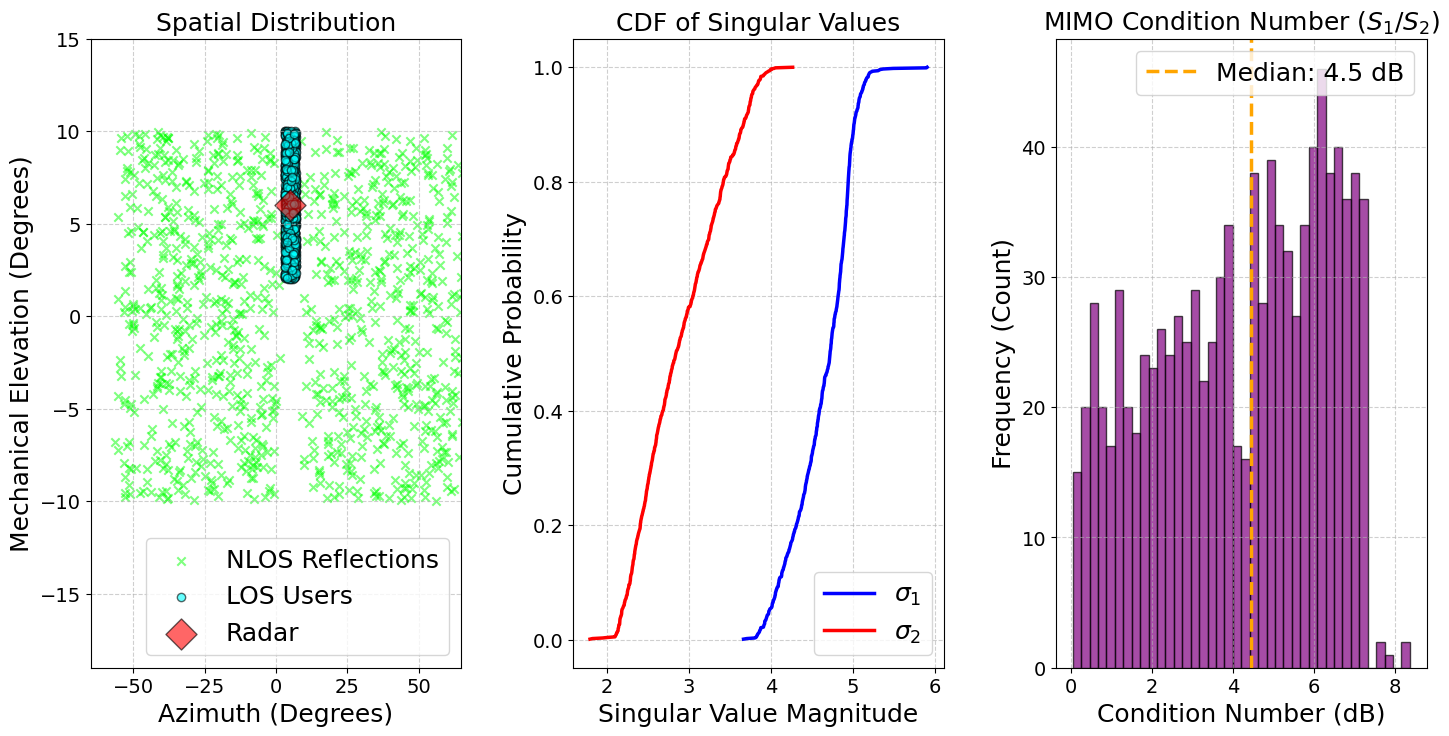

In [24]:
#print("Generating 1000 Stochastic Channels...")

# 1. RUN THE BATCH (Assuming the function is loaded and modified to return angles)
batch_size = 1000
# For this script to run, ensure your function returns: H_total, tx_los_az, tx_los_zenith, tx_nlos_az, tx_nlos_zenith
H_batch, tx_los_az, tx_los_zen, tx_nlos_az, tx_nlos_zen = generate_stochastic_hardware_channel(
    batch_size, y_coords, z_coords, M_analog_tensor, device
)

# 2. PERFORM BATCH SVD
# PyTorch handles batched SVD natively! 
# H_batch shape: [1000, 4, 32] -> S shape: [1000, 4]
U, S, Vh = torch.linalg.svd(H_batch.cpu())

# Extract Singular Values
S1 = S[:, 0].numpy()
S2 = S[:, 1].numpy()

# Calculate Condition Number (S1 / S2) in dB
# Add a tiny epsilon to prevent divide-by-zero if S2 completely collapses
condition_number_db = 20 * np.log10(S1 / (S2 + 1e-12))

# 3. SETUP OBJECT-ORIENTED PLOTTING
# Create a 1x3 grid of subplots
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 8))

# ==========================================
# PLOT 1: The Geometric Scatter (Inputs)
# ==========================================
ax = axes[0]
# Convert PyTorch tensors to NumPy for plotting
az_los = tx_los_az.cpu().numpy()
el_los = tx_los_zen.cpu().numpy()
az_nlos = tx_nlos_az.cpu().numpy()
el_nlos = tx_nlos_zen.cpu().numpy()

# Convert Zenith (0 to 180) back to Mechanical Elevation (+90 to -90) for human readability
ax.scatter(az_nlos, 90 - el_nlos, c='lime', alpha=0.5, marker='x', label='NLOS Reflections')
ax.scatter(az_los, 90 - el_los, c='cyan', alpha=0.6, marker='o', edgecolor='black', label='LOS Users')

ax.scatter(5, 6, c='red', alpha=0.6, marker='D', edgecolor='black', label='Radar',s=250)

ax.set_title("Spatial Distribution", fontsize=18)
ax.set_xlabel("Azimuth (Degrees)", fontsize=18)
ax.set_ylabel("Mechanical Elevation (Degrees)", fontsize=18)
ax.set_xlim(-65, 65)
ax.set_ylim(-19, 15) # Zoomed in to see the horizon sliver
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='lower right',fontsize=18)
ax.tick_params(axis='both', labelsize=14) 

# ==========================================
# PLOT 2: CDF of Singular Values (Math)
# ==========================================
ax = axes[1]
# Calculate empirical CDFs
S1_sorted = np.sort(S1)
S2_sorted = np.sort(S2)
p = np.arange(1, batch_size + 1) / batch_size

ax.plot(S1_sorted, p, color='blue', linewidth=2.5, label=r'$\sigma_1$')
ax.plot(S2_sorted, p, color='red', linewidth=2.5, label=r'$\sigma_2$')

ax.set_title("CDF of Singular Values", fontsize=18)
ax.set_xlabel("Singular Value Magnitude", fontsize=18)
ax.set_ylabel("Cumulative Probability", fontsize=18)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='lower right',fontsize=18)
ax.tick_params(axis='both', labelsize=14) 

# ==========================================
# PLOT 3: Condition Number Histogram (Feasibility)
# ==========================================
ax = axes[2]
# Plot histogram of the condition number
n, bins, patches = ax.hist(condition_number_db, bins=40, color='purple', edgecolor='black', alpha=0.7)

ax.set_title("MIMO Condition Number ($S_1 / S_2$)", fontsize=18)
ax.set_xlabel("Condition Number (dB)",fontsize=18)
ax.set_ylabel("Frequency (Count)",fontsize=18)

# Add a vertical line to show the median condition number
median_cond = np.median(condition_number_db)
ax.axvline(median_cond, color='orange', linestyle='dashed', linewidth=2.5, 
           label=f'Median: {median_cond:.1f} dB')

ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper right',fontsize=18)
ax.tick_params(axis='both', labelsize=14) 

# Final layout adjustments
plt.tight_layout(pad=3.0)
#plt.savefig("LOS_NLOS_Channel_Dist.pdf", bbox_inches="tight",dpi=300)
plt.show()

## Phase 3.5 - Link Level Simulation (LLS)

In [25]:
## MIMO with SVD/3gpp precoding on True Hardware Stochastic Channel
class Phase3PrecoderPipeline(nn.Module):
    # [FIX 1] Added hardware parameters to initialization
    def __init__(self, w_codebook_np, hpbw_mask_np, eps15_mask_np, y_coords, z_coords, M_analog):
        super().__init__()
        
        self.k = 490  
        self.n = 1024 
        self.num_bits_per_symbol = 4 # 16-QAM
        self.coderate = self.k / self.n
        
        self.num_tx_ant = 32
        self.num_rx_ant = 4
        self.num_layers = 2
        
        self.encoder = sn_phy.fec.ldpc.LDPC5GEncoder(self.k, self.n)
        self.decoder = sn_phy.fec.ldpc.LDPC5GDecoder(self.encoder, num_iter=8, return_infobits=True)
        self.mapper = sn_phy.mapping.Mapper("qam", self.num_bits_per_symbol)
        self.demapper = sn_phy.mapping.Demapper("app", "qam", self.num_bits_per_symbol)

        self.num_pms = 2048
        
        W_tensor = torch.tensor(np.array(w_codebook_np), dtype=torch.cfloat)
        self.W_codebook = nn.Parameter(W_tensor, requires_grad=False)
        
        self.hpbw_mask = nn.Parameter(torch.tensor(hpbw_mask_np, dtype=torch.bool), requires_grad=False)
        self.eps15_mask = nn.Parameter(torch.tensor(eps15_mask_np, dtype=torch.bool), requires_grad=False)
        #torch.rand(2048) > 0.95
        
        # Store hardware geometry
        self.y_coords = y_coords
        self.z_coords = z_coords
        self.M_analog = torch.tensor(M_analog, dtype=torch.cfloat)

    def forward(self, batch_size, ebno_db, strategy, device):
        # 1. Baseband (Bits -> QAM -> Layers)
        b = torch.randint(0, 2, (batch_size, self.k), dtype=torch.float32, device=device)
        c = self.encoder(b)
        x = self.mapper(c)
        num_symbols_per_layer = x.shape[1] // self.num_layers
        x_layers = x.view(batch_size, num_symbols_per_layer, self.num_layers, 1)

        # -------------------------------------------
        # [FIX 2] INJECT STOCHASTIC HARDWARE CHANNEL
        # -------------------------------------------
        # We call our external physics engine. We only need H, so we ignore the returned angles.
        H, _, _, _, _ = generate_stochastic_hardware_channel(
            batch_size, self.y_coords, self.z_coords, self.M_analog, device
        )

        ebno_linear = 10.0 ** (ebno_db / 10.0)
        bits_total = self.num_layers * self.num_bits_per_symbol * self.coderate
        eb = 1.0 / bits_total
        no = eb / ebno_linear

        # -------------------------------------------
        # 2. INTELLIGENT PRECODER SELECTION
        # -------------------------------------------
        if strategy == "SVD":
            _, _, Vh = torch.linalg.svd(H.cpu(), full_matrices=False)
            Vh = Vh.to(device)
            V = Vh.mH 
            W_opt = V[:, :, :self.num_layers]
            W_opt = W_opt / np.sqrt(self.num_layers) 
            
        elif strategy.startswith("3GPP"):
            H_eff_all = torch.einsum('b r t, k t l -> b k r l', H, self.W_codebook)
            H_eff_H = H_eff_all.mH
            I = torch.eye(self.num_layers, dtype=torch.cfloat, device=device).view(1, 1, self.num_layers, self.num_layers)
            
            R = torch.matmul(H_eff_H, H_eff_all) + (no * I)
            E = torch.linalg.inv(R)
            
            E_diag = torch.diagonal(E, dim1=-2, dim2=-1).real
            SINR = (1.0 / (no * E_diag)) - 1.0
            
            Capacity = torch.sum(torch.log2(1.0 + torch.clamp(SINR, min=0)), dim=-1) 
            
            if strategy == "3GPP_HPBW":
                Capacity[:, ~self.hpbw_mask] = -float('inf')
            elif strategy == "3GPP_EPS15":
                Capacity[:, ~self.eps15_mask] = -float('inf')

            
            #best_pmi_indices_all = torch.argmax( ##
                    #torch.sum(torch.log2(1.0 + torch.clamp(SINR, min=0)), dim=-1), 
                    #dim=-1
                #)  # best PM WITHOUT mask
            
            
            best_pmi_indices = torch.argmax(Capacity, dim=-1) 

            #changed = (best_pmi_indices != best_pmi_indices_all).float().mean() ##
            #print(f"Fraction of batches where mask changed PM: {changed:.3f}") ##

            W_opt = self.W_codebook[best_pmi_indices] / np.sqrt(self.num_layers)

        # -------------------------------------------
        # 3. Transmit, Channel, Receive
        # -------------------------------------------
        W_expanded = W_opt.unsqueeze(1) 
        H_expanded = H.unsqueeze(1)     
        
        s = torch.matmul(W_expanded, x_layers)
        y_clean = torch.matmul(H_expanded, s)
        
        noise_tensor = torch.randn_like(y_clean) * np.sqrt(no / 2.0)
        y = y_clean + noise_tensor

        # -------------------------------------------
        # 4. MMSE Equalizer & Symbol Unbiasing
        # -------------------------------------------
        H_eff = torch.matmul(H_expanded, W_expanded)
        H_eff_H = H_eff.mH
        I_eq = torch.eye(self.num_layers, dtype=torch.cfloat, device=device).view(1, 1, self.num_layers, self.num_layers)
        
        covariance_eq = torch.matmul(H_eff_H, H_eff) + (no * I_eq)
        G_mmse = torch.matmul(torch.linalg.inv(covariance_eq), H_eff_H) 
        
        x_hat_biased = torch.matmul(G_mmse, y)
        
        D = torch.matmul(G_mmse, H_eff)
        d_k = torch.diagonal(D, dim1=-2, dim2=-1).unsqueeze(-1)
        
        x_hat_unbiased = x_hat_biased / d_k
        
        d_k_real = torch.clamp(d_k.real, min=1e-6, max=1.0 - 1e-6)
        sinr_k = d_k_real / (1.0 - d_k_real)
        no_eff = 1.0 / sinr_k 
        
        # 5. Demap & Decode
        no_eff_expand = no_eff.expand(-1, num_symbols_per_layer, -1, -1).reshape(batch_size, -1)
        x_hat_flat = x_hat_unbiased.reshape(batch_size, -1)
        
        llr = self.demapper(x_hat_flat, no_eff_expand)
        b_hat = self.decoder(llr)
        
        return b, b_hat


# ==========================================
# EXECUTION SCRIPT
# ==========================================
print("Initializing Phase 3.5 True-Hardware Precoder Simulator...")

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Executing on: {device}")

# [FIX 3] Pass the geometric hardware arrays into the model
model = Phase3PrecoderPipeline(
    W_codebook, hpbw_survivor_mask, eps_15_survivor_mask, 
    y_coords, z_coords, M_analog
).to(device)

ebno_dbs = np.arange(-20.0, 25.0, 0.5) 
strategies = ["SVD", "3GPP_ALL", "3GPP_HPBW", "3GPP_EPS15"]

#strategies = ["3GPP_ALL", "3GPP_HPBW", "3GPP_EPS15"]

results = {s: [] for s in strategies}
snrs = {s: [] for s in strategies}

batch_size = 1000 
target_errors = 5000 
max_batches = 250
ber_tripwire = 1e-4

for strategy in strategies:
    print(f"\n--- Running Precoding Strategy: {strategy} ---")
    for ebno_db in ebno_dbs:
        total_errors = 0
        total_bits = 0
        batches_run = 0
        
        with torch.no_grad(): 
            while total_errors < target_errors and batches_run < max_batches:
                b, b_hat = model(batch_size, ebno_db, strategy, device)
                errors = torch.sum(b != b_hat).item()
                total_errors += errors
                total_bits += b.numel()
                batches_run += 1
                
        ber = total_errors / total_bits
        results[strategy].append(ber)
        snrs[strategy].append(ebno_db)
        
        print(f"Eb/N0: {ebno_db:4.1f} dB | Errors: {total_errors:5.0f} | Bits: {total_bits:9.0f} | BER: {ber:.6e}")
        
        if ber < ber_tripwire:
            print(f"  -> [TRIPWIRE ACTIVATED] BER dropped below {ber_tripwire}. Moving to next strategy.")
            break
            
    torch.cuda.empty_cache()
    gc.collect()

Initializing Phase 3.5 True-Hardware Precoder Simulator...
Executing on: cuda:0

--- Running Precoding Strategy: SVD ---
Eb/N0: -20.0 dB | Errors: 186456 | Bits:    490000 | BER: 3.805224e-01
Eb/N0: -19.5 dB | Errors: 182804 | Bits:    490000 | BER: 3.730694e-01
Eb/N0: -19.0 dB | Errors: 179009 | Bits:    490000 | BER: 3.653245e-01
Eb/N0: -18.5 dB | Errors: 175756 | Bits:    490000 | BER: 3.586857e-01
Eb/N0: -18.0 dB | Errors: 171568 | Bits:    490000 | BER: 3.501388e-01
Eb/N0: -17.5 dB | Errors: 166983 | Bits:    490000 | BER: 3.407816e-01
Eb/N0: -17.0 dB | Errors: 161265 | Bits:    490000 | BER: 3.291122e-01
Eb/N0: -16.5 dB | Errors: 156395 | Bits:    490000 | BER: 3.191735e-01
Eb/N0: -16.0 dB | Errors: 151018 | Bits:    490000 | BER: 3.082000e-01
Eb/N0: -15.5 dB | Errors: 145009 | Bits:    490000 | BER: 2.959367e-01
Eb/N0: -15.0 dB | Errors: 139572 | Bits:    490000 | BER: 2.848408e-01
Eb/N0: -14.5 dB | Errors: 132500 | Bits:    490000 | BER: 2.704082e-01
Eb/N0: -14.0 dB | Errors: 1

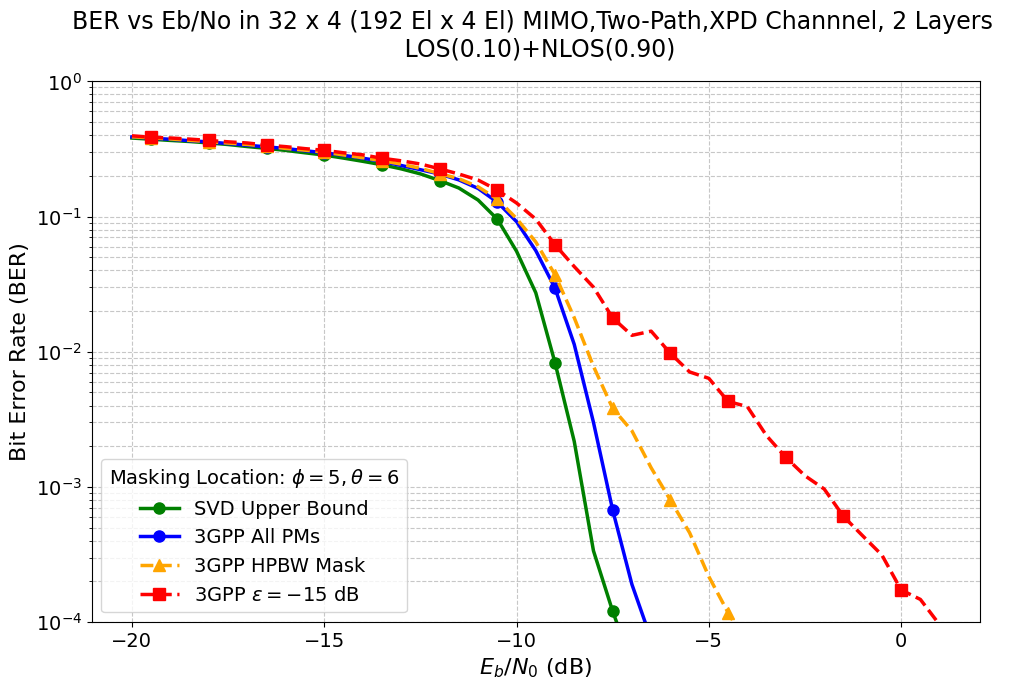

In [26]:
# ==========================================
# PLOTTING
# ==========================================
plt.figure(figsize=(10, 7))

colors = {'SVD': 'green', '3GPP_ALL': 'blue', '3GPP_HPBW': 'orange', '3GPP_EPS15': 'red'}
markers = {'SVD': 'o', '3GPP_ALL': 'o', '3GPP_HPBW': '^', '3GPP_EPS15': 's'}
lines = {'SVD': '-', '3GPP_ALL': '-', '3GPP_HPBW': '--', '3GPP_EPS15': '--'}
labels = {'SVD': 'SVD Upper Bound', '3GPP_ALL': '3GPP All PMs', '3GPP_HPBW': '3GPP HPBW Mask', '3GPP_EPS15': r'3GPP $\epsilon = -15$ dB'}

for strategy in strategies:
    if len(snrs[strategy]) > 0:
        plt.semilogy(snrs[strategy], results[strategy], 
                     color=colors[strategy], linestyle=lines[strategy], 
                     marker=markers[strategy], markevery=(1, 3),
                     linewidth=2.5, markersize=8, 
                     label=labels[strategy])


plt.title("BER vs Eb/No in 32 x 4 (192 El x 4 El) MIMO,Two-Path,XPD Channnel, 2 Layers \n LOS(0.10)+NLOS(0.90)", fontsize=17,y=1.03)
plt.xlabel(r"$E_b/N_0$ (dB)", fontsize=16)
plt.ylabel("Bit Error Rate (BER)", fontsize=16)
plt.grid(True, which="both", linestyle="--", alpha=0.7)
plt.ylim([1e-4, 1])
plt.legend(fontsize=14,title=r'Masking Location: $\phi=5,\theta=6$',loc='lower left',title_fontsize=14)
plt.xticks(fontsize=14) 
plt.yticks(fontsize=14) 
plt.tight_layout()
#plt.savefig("LOS_NLOS_3.pdf", bbox_inches="tight",dpi=300)
plt.show()

## Phase 4 - Ray Tracing

In [365]:
## --- Phase 4.1: Scene Initialization & Hardware Deployment ---

# 1. LOAD THE SCENE
# We load the built-in Paris (Etoile) scene to give us actual 
# buildings and streets to visualize our deployment against.
scene = load_scene(sionna.rt.scene.etoile)

# Look at all the materials currently loaded in your scene
print("Available materials:", scene.radio_materials.keys())

# Grab the specific materials from the dictionary
concrete = scene.radio_materials["concrete"]
marble = scene.radio_materials["marble"]
metal = scene.radio_materials["metal"]
wood = scene.radio_materials["wood"]

# Assign highly contrasting RGB colors [R, G, B]
concrete.color = [0.2, 0.2, 0.2]  # Dark Charcoal
marble.color = [0.0, 0.8, 1.0]     # Bright Cyan 
metal.color = [1.0, 0.0, 0.0]     # Neon Red (Highlight sharp metal edges)
wood.color = [0 , 1 , 0]

# Set the global 5G center frequency
scene.frequency = 3.75e9 

# Calculate wavelength (lambda) for reference
lambda_0 = 3e8 / scene.frequency

# 2. HARDWARE GEOMETRY: gNB Base Station (URA)
# 8 rows * 12 cols = 96 elements. Dual-pol = 192 total RF ports. Standard is half-wavelength (0.5)
tx_array = PlanarArray(
    num_rows=8,
    num_cols=12,
    vertical_spacing=0.5,   # Spacing in multiples of lambda
    horizontal_spacing=0.5, # Spacing in multiples of lambda
    pattern="tr38901",      # 3GPP 3D element pattern
    polarization="cross"     # Natively creates +/- 45 deg cross-pol
)
# Attach this array configuration to all transmitters (only one here for now) in the scene
scene.tx_array = tx_array

# 3. HARDWARE GEOMETRY: Mobile Station (UE)
# 1 row * 2 cols = 2 elements. Dual-pol = 4 total RF ports.
rx_array = PlanarArray(
    num_rows=1,
    num_cols=2,
    vertical_spacing=0.5,   # Spacing in multiples of lambda
    horizontal_spacing=0.5, # Spacing in multiples of lambda
    pattern="tr38901",
    polarization="cross"
)
# Attach this array configuration to all receivers(there will be multiple) in the scene
scene.rx_array = rx_array

# 4. DEPLOY THE BASE STATION (gNB)
# Place the base station high up on a building corner. 
# For later we have to take the coordinate from Blender
# Right Hand Coordinate system, Z up, origin of X,Y in middle 
gnb_position = np.array([220.0, 30.0, 25.0]) # [X, Y, Z] in meters

# Orientation: [yaw, pitch, roll] in radians. 
# Let's face it slightly down (-15 deg) and point it down the main street.
yaw = float(np.deg2rad(45))
pitch = float(np.deg2rad(-15))
roll = 0.0

tx = Transmitter(name="gNB_Sector_1", position=gnb_position, orientation=[yaw, pitch, roll],display_radius=2.0)
scene.add(tx)
print(f"Deployed gNB at {gnb_position} facing Yaw: 45°, Pitch: -15°")

# 5. SECTOR-BASED UE DROPPING (Spherical Geometry)
# Here Look at the Average codebook pattern to decide where does placement makes sense
num_users = 100

# Define the sector boundaries (relative to the gNB's facing direction)
radius_min = 10.0   # Minimum distance from tower (meters)
radius_max = 250.0  # Maximum coverage distance (meters)
azimuth_spread = np.deg2rad(60) # Coverage spanning +/- 60 degrees horizontally
# Panel zenith is 90+pitch = 105,  We cover +-10 degree elevation 
# This is well within the +10 to -10 hotspot in EIRP.
zenith_min = np.deg2rad(95)     # Pointing slightly downwards (90 is horizon)
zenith_max = np.deg2rad(115)    # Pointing steeply downwards

print(f"Dropping {num_users} UEs inside the sector boundaries...")

for i in range(num_users):
    # 1. Generate random spherical coordinates within our defined sector limits
    r = np.random.uniform(radius_min, radius_max)
    theta_zenith = np.random.uniform(zenith_min, zenith_max) #global
    phi_azimuth = np.random.uniform(-azimuth_spread, azimuth_spread) #offset
    
    # We must add the gNB's absolute yaw to the local azimuth 
    # so the sector originates from the direction the gNB is facing
    global_phi = yaw + phi_azimuth
    
    # 2. Convert Spherical to Cartesian [X, Y, Z]
    x_offset = r * np.sin(theta_zenith) * np.cos(global_phi)
    y_offset = r * np.sin(theta_zenith) * np.sin(global_phi)
    z_offset = r * np.cos(theta_zenith)
    
    # 3. Apply the offset to the gNB's absolute location
    ue_pos_x = gnb_position[0] + x_offset
    ue_pos_y = gnb_position[1] + y_offset
    ue_pos_z = gnb_position[2] + z_offset
    
    # Ensure the UE didn't spawn underground!
    ue_pos_z = max(1.5, ue_pos_z) # Force minimum height to 1.5m (human holding phone)
    
    # 4. Add the UE to the scene
    rx = Receiver(name=f"UE_{i}", position=[float(ue_pos_x), float(ue_pos_y), float(ue_pos_z)], 
                  orientation=[0, 0, 0],display_radius=1)
    scene.add(rx)


# 6. VISUALIZE THE SCENE - using vispy, this only works in VS-Code

with sionna_vispy.patch():
    scene.preview()
    canvas = sionna_vispy.get_canvas(scene)

canvas


Available materials: dict_keys(['marble', 'metal', 'wood', 'concrete'])
Deployed gNB at [220.  30.  25.] facing Yaw: 45°, Pitch: -15°
Dropping 100 UEs inside the sector boundaries...


RFBOutputContext()

In [366]:
## Use Path Solver to get all paths

# Initialize the solver engine
p_solver = PathSolver()

# Compute the paths for all 100 UEs simultaneously using the new API
all_users_paths = p_solver(
    scene=scene,
    max_depth=4,               # Allow up to 3/4/5 bounces
    los=True,                  # Calculate direct Line-of-Sight
    specular_reflection=True,  # Bounces off glass/metal
    diffuse_reflection=True,  # Keep False if to save memory
    refraction=True,           # Allows rays to penetrate through concrete!
    synthetic_array=True      # Doesnt Traces exact physical distances for all 192 ports, Does Planar Wave Calculation
)
# Returns a path object 
# Path object attributes 
# -> a(Tuple of real and Imag of shape [num_rx,num_rx_ant,num_tx,num_tx_ant,max_num_paths]
# -> tau (Tuple of num_rx,num_tx,max_num_paths) , far field assumption ie delay is independent of antenna to antenna

# Path Object some Methods 
# -> CIR (Returns a_i(complex, [num_rx,num_rx_ant,num_tx,num_tx_ant,max_num_paths,num_time_steps]) 
# and tau_i[num_rx,num_tx,max_num_paths,num_time_steps])
# -> CFR ( Returns [num_rx, num_rx_ant, num_tx, num_tx_ant, time_steps, subcarriers] )


In [367]:
## See the deadzone and visualize paths for one random user 

# INSPECT THE DRJIT MASK
original_valid = all_users_paths.valid # A mask with shape [num_rx,num_tx,max_paths]

# Convert to standard NumPy so we can safely count the paths
valid_np = np.array(original_valid)

# COUNT USERS WITH ZERO VALID PATHS

#  Sum over the TX and path dimensions to get the total valid paths per receiver
paths_per_user = np.sum(valid_np, axis=(1, 2)) # Resulting shape: [num_rx] (e.g., 100 elements)

#  Identify indices where the total number of paths is exactly 0
dead_zone_indices = np.where(paths_per_user == 0)[0]
num_dead_users = len(dead_zone_indices)

# Print the diagnostic summary
print("---  Outage Diagnostic ---")
print(f"Total Users Evaluated : {len(paths_per_user)}")
print(f"Users with 0 Paths    : {num_dead_users} ({num_dead_users / len(paths_per_user) * 100:.1f}%)")
print(f"Users with Active Links: {len(paths_per_user) - num_dead_users}")

if num_dead_users > 0:
    print(f"\nOutage User Names: {[f'UE_{idx}' for idx in dead_zone_indices]}")
else:
    print("\n Excellent! Every single user in the sector has at least one valid propagation path.")

# 1. SELECT A RANDOM USER
random_user_idx = np.random.randint(0, 100)
target_name = f"UE_{random_user_idx}" # The Name we gave earlier

# We must find the exact tensor index of the user. 
# Sionna's internal tensors match the order of the scene.receivers dictionary.
rx_names = list(scene.receivers.keys())
tensor_idx = rx_names.index(target_name)

print(f"\n[Selection] Target: {target_name} (Tensor Index: {tensor_idx})")

user_path_count = np.sum(valid_np[tensor_idx, :, :])
print(f"Valid Paths found for {target_name}: {user_path_count}")

# 3. RENDER
if user_path_count == 0:
    print(f"⚠️  {target_name} is in a complete RF dead-zone (0 paths).")
    print("Sionna's visualizer will crash if fed 0 lines. Please re-run to pick a different user!")
else:
    # Create the blank mask
    target_mask_np = np.zeros_like(valid_np)
    # Turn on only our target
    target_mask_np[tensor_idx, :, :] = True
    
    # Convert back to DrJit and apply the bitwise AND
    DrJitTensorType = type(original_valid)
    target_mask_drjit = DrJitTensorType(target_mask_np)
    all_users_paths._valid = original_valid & target_mask_drjit # Temporary changing
    
    print("Opening 3D canvas...")
    
    with sionna_vispy.patch():
        scene.preview(paths=all_users_paths)
        canvas = sionna_vispy.get_canvas(scene)
# Restore the global state for baseband generation
all_users_paths._valid = original_valid # Restore (IMPORTANT)

canvas # The end line must be the canvas

---  Outage Diagnostic ---
Total Users Evaluated : 100
Users with 0 Paths    : 19 (19.0%)
Users with Active Links: 81

Outage User Names: ['UE_1', 'UE_8', 'UE_11', 'UE_13', 'UE_18', 'UE_22', 'UE_25', 'UE_26', 'UE_28', 'UE_31', 'UE_37', 'UE_39', 'UE_54', 'UE_55', 'UE_58', 'UE_61', 'UE_91', 'UE_95', 'UE_98']

[Selection] Target: UE_66 (Tensor Index: 66)
Valid Paths found for UE_66: 5
Opening 3D canvas...


RFBOutputContext()


Extracting Power Delay Profile for UE_12...
Total Valid Bounces : 3
Strongest Path Time : 0.00 ns
RMS Delay Spread    : 117.03 ns


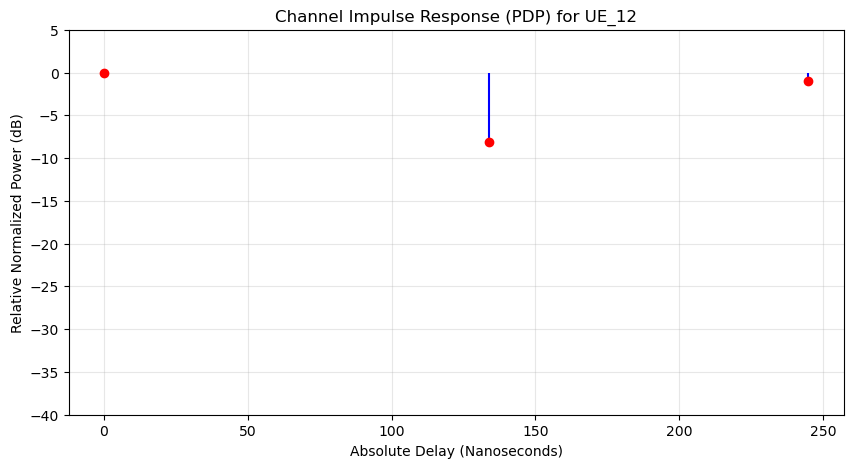

In [368]:
## For a specific user, get the PDP (power delay profile)


# 1. GENERATE THE FULL BASEBAND IMPULSE RESPONSE
# It returns the dense PyTorch baseband tensors for all 100 users!
a_np, tau_np = all_users_paths.cir(normalize_delays=True, out_type="numpy")

# Shape format: [num_rx, num_rx_ant, num_tx, num_tx_ant, max_paths, time_steps] , [num_rx, num_tx, max_paths, time_steps]


# 2. SELECT AN ACTIVE TARGET USER
# We use previous logic to make sure we don't pick a dead-zone user
valid_mask_np = np.array(all_users_paths.valid)
paths_per_user = np.sum(valid_mask_np, axis=(1, 2))
active_users = np.where(paths_per_user > 0)[0]

target_idx = np.random.choice(active_users)
print(f"\nExtracting Power Delay Profile for UE_{target_idx}...")


# 3. ISOLATE AND CLEAN THE USER'S DATA
# Index into the massive tensors to grab just our target.
# We use squeeze() to drop the dimensions of size 1
user_a = np.squeeze(a_np[target_idx])    # Becomes [4, 192, max_paths]
user_tau = np.squeeze(tau_np[target_idx]) # Becomes [max_paths]

# Grab the boolean mask for this specific user to drop Sionna's zero-padded "ghost" paths
user_mask = valid_mask_np[target_idx, 0, :]

# Filter the tensors so we only process rays that physically exist
valid_a = user_a[:, :, user_mask]
valid_tau = user_tau[user_mask]


# 4. COMPUTE THE POWER DELAY PROFILE (PDP)
# The total power of a single path is the sum of its squared magnitudes 
# across ALL 4 receive ports and ALL 192 transmit ports.
path_powers_linear = np.sum(np.abs(valid_a)**2, axis=(0, 1))

# Convert to dB scale (normalized to the strongest path for clean plotting)
max_power = np.max(path_powers_linear)
path_powers_db = 10 * np.log10(path_powers_linear / max_power)

# 5. COMPUTE RMS DELAY SPREAD
# RMS Delay Spread = sqrt( E[tau^2] - E[tau]^2 )
# Expected values are weighted by the linear power of each arriving path.
total_power = np.sum(path_powers_linear)
mean_tau = np.sum(path_powers_linear * valid_tau) / total_power
mean_tau_sq = np.sum(path_powers_linear * (valid_tau**2)) / total_power
rms_delay_spread = np.sqrt(mean_tau_sq - mean_tau**2)

print(f"Total Valid Bounces : {len(valid_tau)}")
print(f"Strongest Path Time : {valid_tau[np.argmax(path_powers_linear)] * 1e9:.2f} ns")
print(f"RMS Delay Spread    : {rms_delay_spread * 1e9:.2f} ns")

# 6. PLOT THE CHANNEL IMPULSE RESPONSE
plt.figure(figsize=(10, 5))
# Plot vertical stems representing energy spikes arriving over time
plt.stem(valid_tau * 1e9, path_powers_db, basefmt=" ", markerfmt="ro", linefmt="b-")
plt.title(f"Channel Impulse Response (PDP) for UE_{target_idx}")
plt.xlabel("Absolute Delay (Nanoseconds)")
plt.ylabel("Relative Normalized Power (dB)")
plt.grid(True, alpha=0.3)
plt.ylim([-40, 5]) # Show paths up to 40 dB weaker than the main ray
plt.show()

Global h_freq shape: (100, 4, 1, 192, 1, 1024)


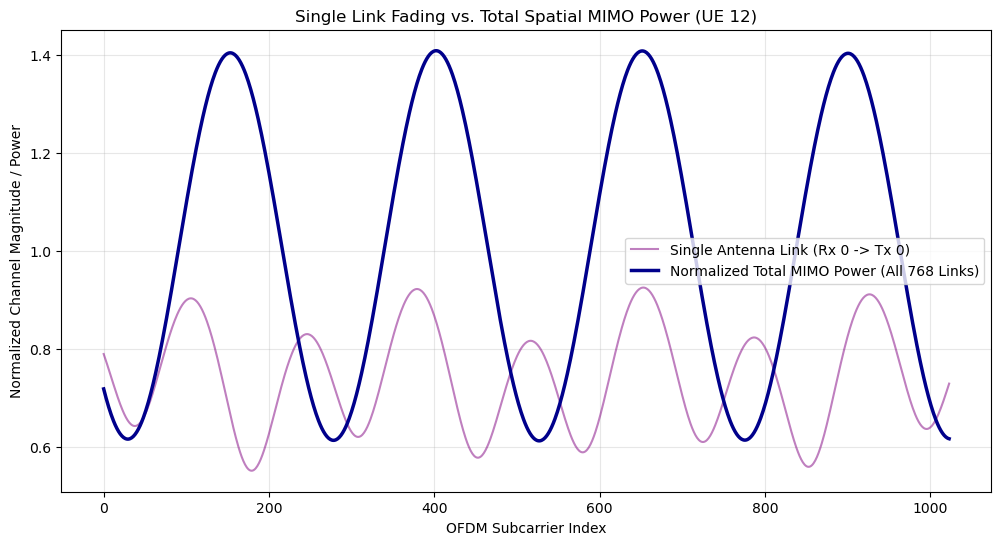

In [369]:
## Compute Frequency response (w/o mobility and timestep for one user)


# 1. DEFINE BASEBAND GRID , Will be centered around the scene.fc
num_subcarriers = 1024
subcarrier_spacing = 30e3

# Sionna requires the frequency offsets to calculate the exact phase rotations
frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)


# 2. BATCH COMPUTE THE FREQUENCY RESPONSE
# This converts the physical rays into the OFDM subcarrier math for ALL 100 users
h_freq = all_users_paths.cfr(
    frequencies=frequencies,
    normalize=True,         # normalized across time and frequency to make sure each Frobenium norm of H (Nt,Nr,num_sc) is Nt x Nrx num_sc
    normalize_delays=True,  #  Shifts the first arrival to t=0
    out_type="numpy"
)

print(f"Global h_freq shape: {h_freq.shape}")
# Structure: [num_rx, num_rx_ant, num_tx, num_tx_ant, time_steps, subcarriers]

# 3. EXTRACT THE TARGET USER'S MATRIX
# We use standard NumPy slicing to pull out our randomly selected user,
# and we grab index 0 for the single tx_tower and single time_step.
target_user_h = h_freq[target_idx, :, 0, :, 0, :] # exact (4, 192, 1024) complex matrix!

# Isolate single-link magnitude (Rx 0, Tx 0)
single_link = np.abs(target_user_h[0, 0, :]) # Will vary

# Compute true total MIMO power (Frobenius norm squared)
# We divide by (4 * 192) to normalize it back to an average of 1.0 
# so it's directly comparable on the same scale!
total_mimo_normalized = np.linalg.norm(target_user_h, axis=(0, 1))**2 / (4 * 192) # Should be around 1

# Plot both to witness the spatial diversity gain
plt.figure(figsize=(12, 6))

plt.plot(single_link, label="Single Antenna Link (Rx 0 -> Tx 0)", color="purple", alpha=0.5)
plt.plot(total_mimo_normalized, label="Normalized Total MIMO Power (All 768 Links)", color="darkblue", linewidth=2.5)

plt.xlabel("OFDM Subcarrier Index")
plt.ylabel("Normalized Channel Magnitude / Power")
plt.title(f"Single Link Fading vs. Total Spatial MIMO Power (UE {target_idx})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

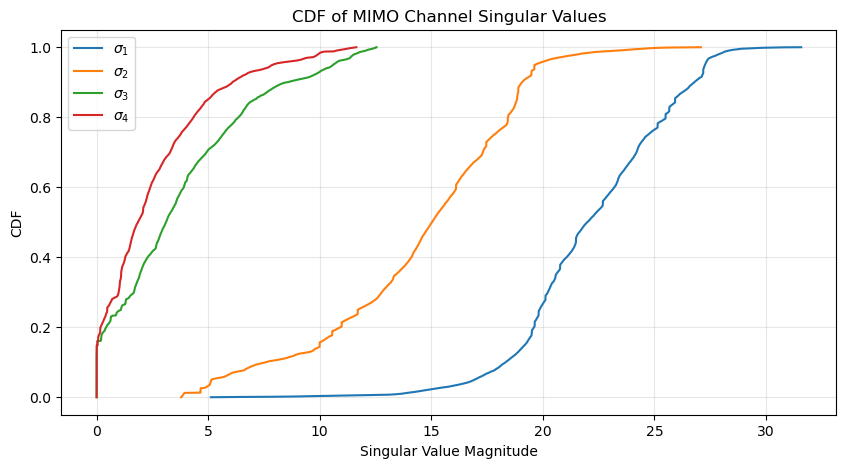

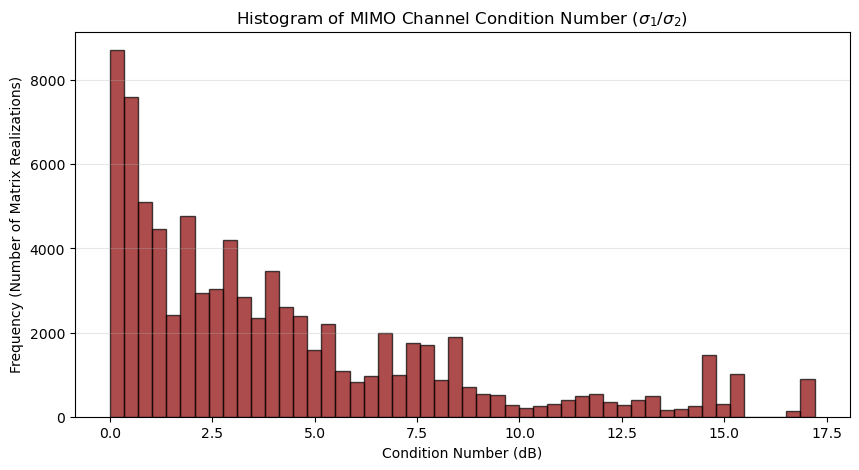

In [370]:
## Channel Rank Analysis

# 1. PREPARE THE TENSOR FOR VECTORIZED SVD
# Assuming your active users tensor has shape: [67, 4, 192, 1024]
# NumPy's SVD operates on the LAST two axes. We need to permute the tensor to shape: [67, 1024, 4, 192]
h_active = h_freq[active_users][:, :, 0, :, 0, :] # Squeezed to [67, 4, 192, 1024]
h_permuted = np.transpose(h_active, (0, 3, 1, 2))  # Becomes [67, 1024, 4, 192]

# Reshape/flatten the user and subcarrier dimensions into a pool of independent matrices
# Shape becomes: [68608, 4, 192]
h_flat = np.reshape(h_permuted, (-1, 4, 192))

# 2. COMPUTE VECTORIZED SVD
# compute_uv=False tells NumPy to only calculate singular values, making it blazing fast
# Returns sorted values: s[:, 0] is largest (sigma_1), s[:, 3] is smallest (sigma_4)
s = np.linalg.svd(h_flat, compute_uv=False) # Shape: [68608, 4]

# Convert to linear power (eigenvalues of H*H^H) or keep as voltage magnitudes
# Standard practice is to look at relative power in dB
s_power = s**2 

# 3. CALCULATE CONDITION NUMBER
# Condition Number = Largest Singular Value / Smallest Singular Value or 2nd Largest singular Value
# Expressed in dB: 20 * log10(sigma_max / sigma_min)
condition_number_db = 20 * np.log10(s[:, 0] / s[:, 1])


# Figure 1: Singular Values CDF
num_points = s.shape[0]
plt.figure(figsize=(10, 5))
for i in range(4):
    sorted_s = np.sort(s[:, i])
    plt.plot(sorted_s, np.arange(1, num_points + 1) / num_points, label=r"$\sigma_{" + str(i+1) + "}$")
plt.xlabel("Singular Value Magnitude")
plt.ylabel("CDF")
plt.title("CDF of MIMO Channel Singular Values")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Figure 2: Condition Number Histogram

plt.figure(figsize=(10, 5))

# Plot the histogram with 50 bins for a smooth distribution shape
plt.hist(condition_number_db, bins=50, color='darkred', edgecolor='black', alpha=0.7)

plt.xlabel("Condition Number (dB)")
plt.ylabel("Frequency (Number of Matrix Realizations)")
plt.title("Histogram of MIMO Channel Condition Number ($\sigma_1 / \sigma_2$)")
plt.grid(True, alpha=0.3, axis='y') # Horizontal grid lines only to read heights easily
plt.show()



Virtualization Matrix M_sionna created! Shape: (192, 32)
Port 1 is mapped to Physical Indices: [ 2  3 10 11 18 19]
Filtered active users. Tensor shape before virtualization: (81, 4, 192, 1024)
Virtualization complete. Tensor shape: (81, 4, 32, 1024)
Flattened matrix pool ready for SVD: (82944, 4, 32)


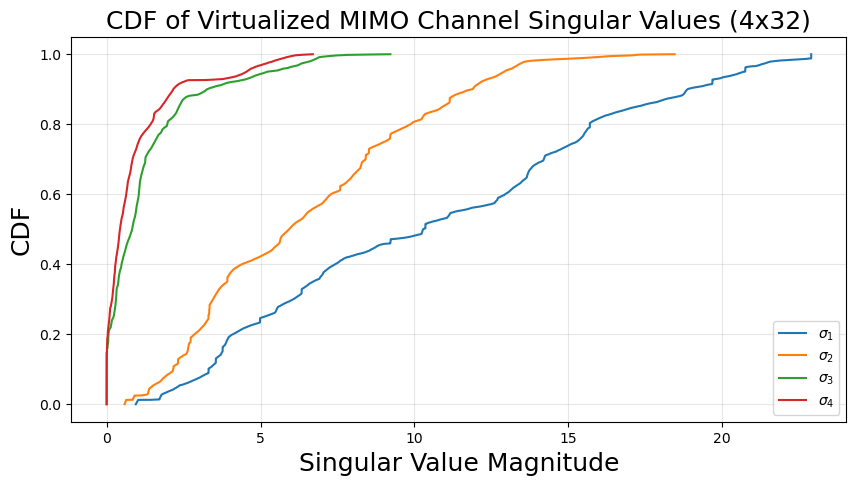

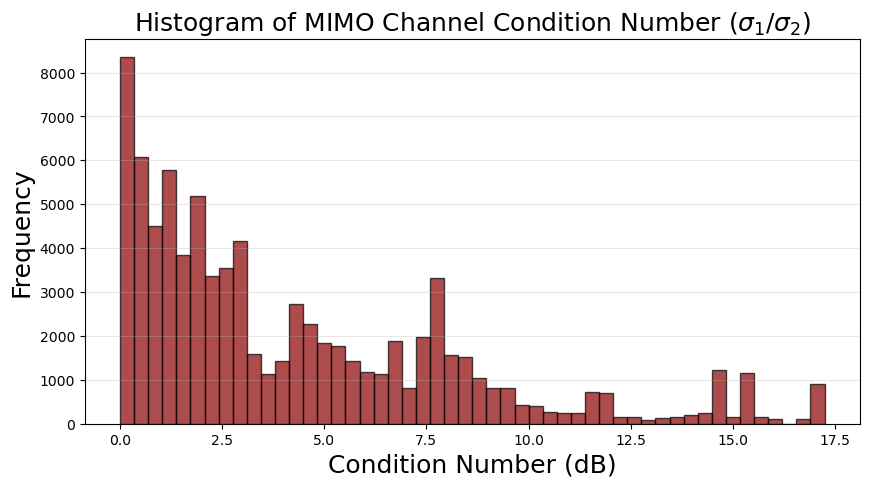

In [371]:
## Antenna Port Virtualization (192 -> 32)
# tx_array.show() ,to see indexing visualization
# INITIALIZE THE TRANSFORMATION MATRIX , Shape: [Physical Antennas, Logical Ports]

M_sionna = np.zeros((192, 32), dtype=complex)

# Normalization scalar to preserve energy when summing 6 elements
weight = 1.0 / np.sqrt(6)

# 2. POPULATE THE MATRIX (Based on your 2x3 mapping)
for pol in range(2):
    # Pol 0 handles elements 0-95 and ports 0-15
    # Pol 1 handles elements 96-191 and ports 16-31
    element_offset = pol * 96
    port_offset = pol * 16
    
    # 4 blocks horizontally (12 cols / 3 cols per block)
    for block_c in range(4): 
        # 4 blocks vertically (8 rows / 2 rows per block)
        for block_r in range(4): 
            
            # Port indexing (column-first down the blocks)
            logical_port_idx = port_offset + (block_r + block_c * 4)
            
            # Map the 6 physical elements inside this specific 2x3 block
            for c in range(3):
                for r in range(2):
                    actual_col = block_c * 3 + c
                    actual_row = block_r * 2 + r
                    
                    # Sionna 1D Indexing: row + col * total_rows
                    physical_element_idx = element_offset + (actual_col * 8) + actual_row
                    
                    # Assign the weight
                    M_sionna[physical_element_idx, logical_port_idx] = weight

print("Virtualization Matrix M_sionna created! Shape:", M_sionna.shape)

# Optional Sanity Check: Prove Port 0 maps to your exact indices (0-based)
port = 1
port_elements = np.where(M_sionna[:, port] > 0)[0]
print(f"Port {port} is mapped to Physical Indices: {port_elements}")
# Expected output: for port=0 [0, 1, 8, 9, 16, 17] (Which is exactly 1,2,9,10,17,18 in 1-based indexing!)


# Filter out inactive users and drop the singleton dimensions (num_tx=0 and time_step=0)
h_active = h_freq[active_users][:, :, 0, :, 0, :]
num_active = h_active.shape[0]
print(f"Filtered active users. Tensor shape before virtualization: {h_active.shape}")

# 2 APPLY M_sionna VIA EINSTEIN SUMMATION (192 -> 32)
# h_active shape:  [r, u, a, t] -> (active_rx, rx_ant=4, tx_phys_ant=192, subcarriers=1024)
# M_sionna shape:  [a, w]      -> (tx_phys_ant=192, tx_virtual_ports=32)
# Output shape:    [r, u, w, t] -> (active_rx, rx_ant=4, tx_virtual_ports=32, subcarriers=1024)

h_virtual = np.einsum('ruat,aw->ruwt', h_active, M_sionna)
print(f"Virtualization complete. Tensor shape: {h_virtual.shape}")

# 3. PREPARE THE TENSOR FOR VECTORIZED SVD
# NumPy SVD computes over the last two axes. 
# We need to transform [num_active, 4, 32, 1024] -> [num_active, 1024, 4, 32]
h_permuted = np.transpose(h_virtual, (0, 3, 1, 2)) 

# Flatten the user and subcarrier axes into a single pool of independent channels
# Shape becomes: [num_active * 1024, 4, 32]
h_flat = np.reshape(h_permuted, (-1, 4, 32))
print(f"Flattened matrix pool ready for SVD: {h_flat.shape}")

# 4. COMPUTE VECTORIZED SVD & CN
# compute_uv=False skips calculating U and V matrices, making it highly optimized
s = np.linalg.svd(h_flat, compute_uv=False)  # Shape: [num_active * 1024, 4]

# Calculate the condition number in dB using the 1st and 2nd singular values
condition_number_db = 20 * np.log10(s[:, 0] / s[:, 1])


# 5. VISUALIZATION
num_points = s.shape[0]

# Figure 1: Singular Values CDF
plt.figure(figsize=(10, 5))
for i in range(4):
    sorted_s = np.sort(s[:, i])
    plt.plot(sorted_s, np.arange(1, num_points + 1) / num_points, label=r"$\sigma_{" + str(i+1) + "}$")
plt.xlabel("Singular Value Magnitude",fontsize=18)
plt.ylabel("CDF",fontsize=18)
plt.title("CDF of Virtualized MIMO Channel Singular Values (4x32)",fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Figure 2: Condition Number Histogram
plt.figure(figsize=(10, 5))
plt.hist(condition_number_db, bins=50, color='darkred', edgecolor='black', alpha=0.7)
plt.xlabel("Condition Number (dB)",fontsize=18)
plt.ylabel("Frequency",fontsize=18)
plt.title(r"Histogram of MIMO Channel Condition Number ($\sigma_1 / \sigma_2$)",fontsize=18)
plt.grid(True, alpha=0.3, axis='y')
plt.show()


In [ ]:
## Next -> Link Level Simulation on the Ray tracing channel to be developed and updated.